# Trabalho Prático de Mineração de Dados — Fase 2
## Utilização de LLMs e Análise Comparativa com Diretrizes de IA Responsável

**Disciplina:** Mineração de Dados  
**Grupo:**  João Marcos Oliveira Neves (2024008644), Júlia Borba Fonseca de Souza (2023117580), Laura Martins Froede (2023087877), Matheus Soares dos Santos de Freitas (2024080043)  
**Dataset:** Credit Card Dataset for Clustering
**Tarefa de mineração:** Agrupamento
**Data da entrega:** 24/05/2026

---

## Objetivo deste notebook

Este notebook documenta a Fase 2 do Trabalho Prático. O objetivo é usar uma ou mais LLMs como apoio à construção da solução de mineração de dados e comparar duas trilhas de interação:

- **Trilha A — baseline:** interação com a LLM sem explicitar diretrizes de IA responsável;
- **Trilha B — guiada:** interação com a LLM explicitando as diretrizes de IA responsável escolhidas pelo grupo.

O foco não é apenas mostrar prompts e respostas. O grupo deve analisar criticamente se a explicitação das diretrizes levou a diferenças concretas na solução proposta, por exemplo em:

- escolha de algoritmos;
- tratamento dos dados;
- seleção de atributos;
- definição de parâmetros;
- métricas de avaliação;
- interpretabilidade;
- privacidade;
- análise de viés;
- custo computacional;
- qualidade da documentação.

> **Importante:** este notebook é um modelo de estrutura. Ele contém exemplos, placeholders e código genérico. O grupo deve substituir os campos indicados por informações reais do seu dataset, das interações com LLMs e dos experimentos efetivamente realizados.


# Como usar este notebook

Este notebook foi organizado seguindo a estrutura esperada para a Fase 2:

1. **Business Understanding**
2. **Data Understanding & Data Preparation**
3. **Modeling**
4. **Evaluation**
5. **Checklist final**

Ao longo do notebook, os trechos marcados entre colchetes, como `[INSERIR LINK DA CONVERSA]`, devem ser preenchidos pelo grupo.

## Diferença entre exemplo e entrega real

- Células de **exemplo** mostram como organizar a entrega.
- Células com **placeholders** indicam pontos que devem ser preenchidos.
- Células de **código** são genéricas e podem precisar de adaptação ao dataset.
- Nenhum resultado experimental deve ser inventado.
- Toda conclusão empírica deve estar apoiada em uma tabela, gráfico ou execução de código.


# 0. Controle da entrega e rastreabilidade

Esta seção registra informações mínimas para tornar o trabalho rastreável e auditável.

| Item | Valor |
|---|---|
| Nome do dataset | Credit Card Dataset for Clustering |
| Link público do dataset | https://www.kaggle.com/datasets/arjunbhasin2013/ccdata |
| Número de linhas | 8950 |
| Número de colunas | 18 |
| Tarefa de mineração | Agrupamento |
| LLM usada na Trilha A | Gemini Pro |
| LLM usada na Trilha B | Gemini Pro |
| Link da conversa — Trilha A | https://gemini.google.com/share/c0b2d5f99d84 |
| Link da conversa — Trilha B |  https://gemini.google.com/share/fd9d1663f006|

## Diretrizes de IA responsável escolhidas

| Diretriz | Justificativa da escolha | Como será explicitada na Trilha B |
|---|---|---|
| Explicabilidade | Algoritmos de clustering dividem o espaço multidimensional de forma puramente matemática. Sem uma tradução semântica, os perfis gerados tornam-se caixas-pretas estatísticas inutilizáveis para equipes de risco e de crédito humanas. | A instrução de modelagem exigirá: "Atue como um Especialista em Ciências Comportamentais Aplicadas a Finanças. Dado o vetor de centroides de cada cluster gerado, traduza as médias numéricas em personas financeiras detalhadas (ex: ’O Consumidor Consciente Parcelador’ ou ’O Usuário Dependente de Saques Emergenciais’), justificando o perfil com base nas variáveis estruturais." |
| Justiça e Viés | Agrupamentos baseados em saldos devedores e capacidade de pagamento mínimo podem criar loops de feedback discriminatórios. Se um cluster rotular sistematicamente indivíduos de menor poder aquisitivo em grupos de "altíssimo risco", o algoritmo pode justificar a redução automática de seus limites, agravando sua vulnerabilidade econômica. | A LLM será guiada pela seguinte restrição: "Atue como um ombudsman de IA Ética. Analise a distribuição de limites e saldos nos clusters gerados. Avalie se o modelo está penalizando desproporcionalmente grupos com menor capacidade de pagamento com rótulos de risco excessivos e sugira formas de balancear a interpretação do cluster para evitar a exclusão financeira injusta." |

> **Propósito pedagógico:** esta seção evita que a análise fique solta ou apenas narrativa. O avaliador precisa conseguir identificar o que foi perguntado à LLM, quando, em qual modelo e com qual objetivo.


In [1]:
# Configurações iniciais do notebook
# Esta célula centraliza imports e parâmetros gerais.
# O grupo deve adaptar os caminhos, nomes de colunas e tipo de tarefa.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Exemplos:
# DATA_PATH = "dados/dataset.csv"
# DATA_PATH = "/content/dataset.csv"
DATA_PATH = "https://raw.githubusercontent.com/Doctor-Math/TPs-Mineracao-de-Dados/VariableMath/data/data_tp2/CC%20GENERAL.xls"

# Tipo de tarefa do TP.
# Opções sugeridas:
# - "padroes_frequentes"
# - "agrupamento"
# - "classificacao"
TASK_TYPE = "Agrupamento"

# Coluna-alvo, se aplicável.
# Para padrões frequentes ou agrupamento, normalmente pode ser None.
TARGET_COLUMN = None  # Exemplo: "classe"

# Coluna ou conjunto de colunas usadas para gerar transações, se o TP for de padrões frequentes.
TRANSACTION_COLUMN = "[INSERIR_COLUNA_DE_TRANSACOES]"

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")


Configuração carregada.
Tarefa definida: Agrupamento


# 1. Business Understanding

Nesta seção, o grupo deve explicar o problema, o contexto dos dados, a relevância da tarefa e a hipótese experimental sobre o uso das diretrizes de IA responsável.

A seção deve responder:

1. Qual problema será investigado?
2. Por que o dataset é relevante?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da análise?
5. Quais diretrizes de IA responsável foram escolhidas?
6. Por que essas diretrizes são pertinentes ao problema?
7. O que se espera que mude quando essas diretrizes são explicitadas à LLM?


## 1.1 Descrição do problema de negócio

- **Contexto:** Instituições financeiras gerenciam milhões de titulares de cartões de crédito ativos, gerando um volume massivo de dados transacionais diários. Em vez de analisar os clientes apenas por métricas isoladas (como o score de crédito tradicional), o banco precisa entender a dinâmica comportamental multidimensional de seus usuários, como a relação entre gastos à vista, parcelamentos, saques emergenciais e o ritmo de pagamento das faturas ao longo do tempo.
- **Problema:** A análise agregada ou baseada em regras estáticas falha em capturar os perfis sutis de consumo e de saúde financeira dos clientes. Sem uma segmentação inteligente e não supervisionada, a instituição financeira não consegue diferenciar o cliente que usa o limite alto com responsabilidade daquele que está operando no limite devido ao superendividamento, o que gera ineficiência na oferta de produtos e aumento no risco de inadimplência (default).
- **Possíveis interessados:**
  - Equipe de Gestão de Risco de Crédito: Interessada em antecipar perfis de risco de endividamento antes que ocorra a inadimplência.
  - Time de Marketing e Produtos Financeiros: Interessado em criar campanhas personalizadas e ajustar benefícios do cartão (milhas, seguros, cashback) para os perfis certos.
  - Analistas de Experiência do Cliente (CX): Focados em identificar clientes insatisfeitos ou subutilizados para ações de engajamento.
- **Decisões apoiadas pela análise:**
  - Realocação automatizada e preventiva de limites de crédito (aumento para perfis saudáveis e redução ou congelamento para perfis de risco).
  - Personalização de políticas de taxas de juros para parcelamentos baseada no histórico comportamental do cluster.
  - Intervenções proativas de saúde financeira (alertas e ofertas de refinanciamento amigável para clusters em vias de superendividamento).
- **Limitações iniciais conhecidas:** O dataset compreende um histórico restrito de apenas 6 meses de atividade, o que impede a análise de sazonalidades anuais longas (como compras de fim de ano). Além disso, a base é estritamente comportamental e anonimizada, não contendo variáveis demográficas essenciais (como idade, profissão ou renda declarada), o que exige que a renda e o contexto do cliente sejam inferidos indiretamente a partir do saldo e do volume de gastos (proxy features).

> Este texto deve ser escrito pelo grupo. Não copie a descrição do dataset sem contextualizar o problema de mineração de dados.


## 1.2 Objetivo do dataset, origem e características gerais

### Objetivo do dataset

O propósito principal deste conjunto de dados é permitir a segmentação de clientes bancários por meio de seus históricos de consumo e pagamento. Ele foi estruturado especificamente para tarefas de aprendizado não supervisionado (clustering), servindo para agrupar usuários com perfis transacionais semelhantes e identificar anomalias ou comportamentos de risco no uso do cartão de crédito.

### Origem dos dados

Os dados são reais e provêm de uma instituição financeira operante no mercado global, tendo sido anonimizados e disponibilizados para fins acadêmicos e de desenvolvimento de modelos. A base é amplamente conhecida e hospedada na plataforma Kaggle.

Link público: https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

### Características do dataset

| Coluna | Tipo esperado | Descrição | Relevância para a tarefa |
|---|---|---|---|
| CUST_ID | object (string) | Identificador único do titular do cartão (mascarado). | Nula. Será removida ou indexada, pois não possui valor preditivo ou comportamental. |
| BALANCE | float32 | Saldo devedor/pendente na conta do cliente para compras. | Altíssima. Indica o montante que o cliente carrega como dívida ativa de um mês para o outro. |
| BALANCE_FREQUENCY | float32 | Frequência com que o saldo é atualizado (relação entre 0 e 1). | Alta. Mede a constância do uso do cartão. Próximo a 1 significa uso diário/contínuo. |
| PURCHASES | float32 | Valor total de compras realizadas nos últimos 6 meses. | Altíssima. Principal indicador do volume de consumo do cliente. |
| ONEOFF_PURCHASES | float32 | Valor máximo de transações feitas em uma única compra (à vista). | Média. Ajuda a diferenciar compradores de itens de alto valor daqueles de gastos fracionados. |
| INSTALLMENTS_PURCHASES | float32 | Valor total de compras realizadas de forma parcelada. | Altíssima. Essencial para testar a Hipótese 1 (separação entre parceladores e compradores à vista). |
| CASH_ADVANCE | float32 | Valor total de saques em dinheiro utilizando o limite do cartão. | Altíssima. Principal indicador de comportamento de risco e busca por liquidez emergencial (Hipótese 2). |
| PURCHASES_FREQUENCY | float32 | Frequência com que as compras são feitas (relação entre 0 e 1). | Alta. Diferencia o comprador assíduo do usuário esporádico. |
| ONEOFF_PURCHASES_FREQUENCY | float32 | Frequência de compras à vista (relação entre 0 e 1). | Média. Mede a adesão ao comportamento de pagamento imediato. |
| PURCHASES_INSTALLMENTS_FREQ | float32 | Frequência de compras parceladas (relação entre 0 e 1). | Média. Mede a dependência do parcelamento no dia a dia. |
| CASH_ADVANCE_FREQUENCY | float32 | Frequência com que são realizados saques em dinheiro. | Alta. Avalia se o comportamento de risco por saques é crônico ou um evento isolado. |
| CASH_ADVANCE_TRX | int32 | Número de transações de saque em dinheiro realizadas. | Média. Quantifica a recorrência de saques de forma discreta. |
| PURCHASES_TRX | int32 | Número de transações de compra realizadas. | Alta. Permite entender o tíquete médio das compras quando cruzada com PURCHASES. |
| CREDIT_LIMIT | float32 | Limite de crédito total concedido ao cliente. | Altíssima. Crucial para avaliar a capacidade financeira e testar a Hipótese 3 (uso do teto disponível). |
| PAYMENTS | float32 | Valor total de pagamentos efetuados pelo cliente nos 6 meses. | Altíssima. Mede a capacidade do cliente de amortizar sua dívida real com o banco. |
| MINIMUM_PAYMENTS | float32 | Valor mínimo de pagamento exigido pela fatura. | Altíssima. Possui dados faltantes (missing values) e indica a propensão ao endividamento rotativo. |
| PRC_FULL_PAYMENT | float32 | Percentual da fatura pago integralmente pelo cliente. | Alta. Identifica os clientes financeiramente saudáveis (que quitam 100% da fatura constantemente). |
| TENURE | int32 | Tempo de relacionamento do cliente com o cartão (em meses). | Baixa. Controla o tempo de observação do comportamento (geralmente fixado em 6 meses nesta base). |


### Relação com o problema de negócio

Este conjunto de dados é perfeito para o problema de negócio proposto porque cobre simultaneamente as três dimensões críticas do comportamento em cartões de crédito: Consumo (PURCHASES), Endividamento (BALANCE, CASH_ADVANCE) e Amortização (PAYMENTS, MINIMUM_PAYMENTS).

Ao contrário de uma base sintética (que geraria padrões perfeitos e artificiais), este dataset possui as imperfeições de um cenário bancário real: distribuições severamente assimétricas (poucos clientes gastam milhões, enquanto a maioria gasta pouco), forte correlação linear entre variáveis (como frequências de compra e volumes gastos) e dados ausentes em contas recém-criadas ou inativas. Isso exigirá o uso rigoroso de técnicas de preparação de dados (como normalização por escala e engenharia de atributos) e permitirá avaliar de forma justa o impacto e a eficiência dos algoritmos K-Means e DBSCAN no Google Colab.

## 1.3 Diretrizes selecionadas e hipótese experimental

### Diretrizes selecionadas

| Diretriz | Por que é pertinente ao problema? | Possível efeito esperado na solução da LLM |
|---|---|---|
| Explicabilidade | Algoritmos de agrupamento (clustering) operam dividindo o espaço matemático multidimensional de forma abstrata. Sem uma tradução semântica dos centroides e das distâncias, as "personas financeiras" geradas tornam-se caixas-pretas estatísticas inutilizáveis por equipes de risco e analistas de negócio humanos. | Espera-se que a LLM guie o grupo na interpretação qualitativa dos centroides, transformando médias puras de colunas como CASH_ADVANCE e INSTALLMENTS_PURCHASES em descrições claras de comportamento (personas), sugerindo também métodos visuais (como mapas de calor e gráficos de coordenadas paralelas) para justificar os grupos gerados. |
| Justiça e Mitigação de Viés | Segmentações baseadas em histórico de adimplência, saldos devedores e pagamento mínimo podem criar loops de discriminação indireta (proxy discrimination). Se o modelo isolar e rotular de forma puramente punitiva grupos de baixa renda sob a alcunha de "altíssimo risco", pode induzir o banco a decisões automatizadas de redução severa de limites, agravando a vulnerabilidade econômica desses clientes. | Espera-se que a LLM alerte sobre o perigo de rotulagem estigmatizante sobre variáveis de capacidade de pagamento, propondo uma avaliação de impacto de equidade e sugerindo restrições éticas na interpretação dos clusters para evitar decisões de exclusão financeira sistemática. |

### Hipótese experimental

Esperamos que, ao explicitar as diretrizes de Explicabilidade e Justiça e Mitigação de Viés, a LLM proponha na trilha guiada uma estratégia de modelagem com maior interpretabilidade analítica (focada na construção e validação de personas financeiras transparentes) e maior cuidado com impactos regulatórios e discriminação indireta, em comparação com a solução baseline (que tende a sugerir apenas métricas e algoritmos matemáticos puros, sem contextualização ética ou de negócios).

### Evidências que serão analisadas

Para avaliar a hipótese, compararemos as trilhas quanto a:
- **algoritmos sugeridos**: se a trilha guiada sugere algoritmos que facilitem a interpretação de centroides (como K-Means) ou detecção de anomalias com justificativa ética (como DBSCAN);
- **etapas de preparação dos dados**: se há inclusão de técnicas para monitorar ou mitigar disparidades de escala que possam enviesar o agrupamento contra perfis específicos;
- **parâmetros recomendados**: como a LLM orienta a escolha do número de clusters ($k$) visando o equilíbrio entre a qualidade estatística e a explicabilidade prática para o negócio;
- **métricas propostas**: se além das métricas internas de agrupamento (Silhueta, Davies-Bouldin), são propostas métricas de validação de viés ou de interpretabilidade das personas;
- **justificativas técnicas**: a profundidade dos argumentos usados para validar a escolha de uma partição espacial específica;riscos apontados: se a LLM mapeia os perigos éticos de loops de feedback discriminatórios causados pela segmentação automatizada;
- **limitações reconhecidas**: o reconhecimento de que perfis demográficos e socioeconômicos ocultos podem estar sofrendo vieses indiretos no modelo;
- **aderência às diretrizes escolhidas**: o grau em que as respostas deixam de ser meros relatórios de código e passam a atuar como um guia de IA Responsável.


## 1.4 Interações com LLM — Business Understanding

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro 
**Data de acesso:** 23/05/2023
**Link da conversa:** https://gemini.google.com/share/c0b2d5f99d84
**Subtarefa:** obter apoio para formular o Business Understanding.

#### Prompt principal — baseline

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset CC GENERAL (Credit Card Dataset para Clustering).
A tarefa principal é aplicar técnicas de agrupamento (Clustering), especificamente extração de padrões frequentes e engenharia de atributos, para segmentar clientes de cartão de crédito e definir estratégias de marketing.

Ajude-me a formular o Business Understanding (Entendimento do Negócio), incluindo o objetivo do uso desse dataset, a origem dos dados, suas características gerais e a relação direta com o problema de negócio de uso de crédito.
```

#### Síntese da resposta da LLM

1. Contexto e Origem dos Dados

O mercado de cartões de crédito é altamente competitivo e dinâmico. Para uma instituição financeira, emitir um cartão é apenas o primeiro passo; o verdadeiro desafio está em entender como o cliente utiliza esse crédito para maximizar a receita (via juros e tarifas) e mitigar riscos (inadimplência), além de reter o cliente.

O dataset CC GENERAL resume o comportamento de uso de aproximadamente 9.000 clientes ativos de cartão de crédito durante um período de 6 meses. Os dados são de nível transacional e de conta, transformados em um perfil consolidado por cliente.
2. O Problema de Negócio

Campanhas de marketing generalistas ("one-size-fits-all") têm baixa taxa de conversão e alto custo. Um cliente que usa o cartão apenas para compras parceladas de alto valor exige uma abordagem completamente diferente daquele que usa o cartão diariamente para pequenas compras, ou daquele que vive no crédito rotativo.

O problema central é: Como segmentar a base de clientes de forma automatizada e baseada em dados para desenhar estratégias de marketing personalizadas, aumentar o uso do cartão (share of wallet) e gerenciar o risco de crédito?
3. Características Gerais dos Dados (Sob a Ótica do Negócio)

Para minerar esses dados com sucesso, as variáveis do dataset devem ser interpretadas através de três pilares de comportamento:
A. Comportamento de Compra (Engajamento)

    PURCHASES: O valor total gasto em compras. Indica o volume de transações.

    ONEOFF_PURCHASES vs INSTALLMENTS_PURCHASES: Compras à vista (geralmente ticket maior ou uso imediato) vs. Compras parceladas (fidelização a médio prazo).

    PURCHASES_FREQUENCY: Com que frequência o cliente usa o cartão. Clientes de alta frequência usam o cartão como principal meio de pagamento diário.

B. Comportamento Financeiro e de Pagamento (Risco e Receita)

    BALANCE: O saldo devedor atual na conta.

    CASH_ADVANCE: Saque em dinheiro utilizando o limite do cartão. Geralmente é um indicador de estresse financeiro ou necessidade urgente de liquidez (alta receita de juros para o banco, mas alto risco).

    PRC_FULL_PAYMENT: A porcentagem da fatura que o cliente paga integralmente. Se for 1, é um Transactor (paga tudo, não gera juros rotativos). Se for próximo de 0, é um Revolver (rola a dívida, gerando muita receita de juros, mas com maior risco de inadimplência).

C. Capacidade de Crédito

    CREDIT_LIMIT: O limite de crédito concedido. Define o teto de gastos e ajuda a calcular a Utilização do Limite (BALANCE / CREDIT_LIMIT), um atributo crítico para engenharia de features.

4. Objetivos da Mineração de Dados (Data Mining Goals)

Para responder ao problema de negócio, o projeto aplicará técnicas de agrupamento (Clustering) para atingir os seguintes objetivos técnicos:

    Identificar Perfis de Clientes (Persona Discovery): Agrupar clientes com base em semelhanças de consumo e pagamento (ex: "Os Gastadores Conscientes", "Os Dependentes de Dinheiro Vivo", "Os Parceladores Assíduos").

    Engenharia de Atributos Estratégicos: Criar novas métricas que o dataset original não traz diretamente, mas que o negócio valoriza, tais como:

        Razão de Saque/Compra: Para entender se o cliente usa o cartão para consumir ou para se financiar.

        Índice de Utilização do Limite: Para identificar clientes que precisam de aumento de limite ou que estão sufocados financeiramente.

    Análise de Padrões Frequentes: Identificar regras de associação ou combinações de comportamentos (ex: alta frequência de compras parceladas está fortemente associada a faturas pagas parcialmente?).
---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro 
**Data de acesso:** 23/05/2026
**Link da conversa:** https://gemini.google.com/share/fd9d1663f006
**Subtarefa:** obter apoio para formular o Business Understanding considerando as diretrizes escolhidas.

#### Prompt principal — guiado

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset CC GENERAL.
A tarefa principal é aplicar técnicas de agrupamento (Clustering) e mineração de padrões frequentes para segmentação de comportamento de clientes de cartões de crédito para fins de marketing.
Ajude-me a formular o Business Understanding.

Considere explicitamente as seguintes diretrizes de IA responsável:
1. Privacidade e Proteção de Dados: Como a análise de saldos (BALANCE), compras (PURCHASES) e saques em dinheiro (CASH_ADVANCE) reflete hábitos financeiros sensíveis dos indivíduos, discuta limites para que a engenharia de atributos não gere perfis excessivamente invasivos ou exponha vulnerabilidades econômicas.
2. Equidade e Prevenção de Discriminação Excludente: Garanta que os clusters gerados para campanhas de marketing ou concessão de benefícios não atuem como um viés punitivo contra perfis de menor renda ou com baixos pagamentos mínimos (MINIMUM_PAYMENTS), perpetuando barreiras econômicas de forma injusta.

Além da descrição do problema, indique riscos éticos, limitações analíticas das variáveis financeiras fornecidas e critérios quantitativos/qualitativos de sucesso que deveriam orientar a solução de mineração de dados.
```

#### Síntese da resposta da LLM

1. Descrição do Problema e Objetivos de Negócio

- Problema: A base de clientes de cartão de crédito possui perfis muito diferentes, e tratá-los da mesma forma reduz a eficácia das estratégias de marketing.

- Objetivo Analítico: Aplicar técnicas de Clustering (K-Means, DBSCAN ou Hierárquico) para identificar perfis de clientes e usar Mineração de Padrões Frequentes para encontrar relações entre comportamentos de uso.

- Objetivo de Negócio: Criar campanhas personalizadas (recompensas, upgrades e crédito adequado) para aumentar engajamento e rentabilidade.


2. Diretrizes de IA Responsável
- Privacidade e Proteção de Dados: Priorizar padrões de comportamento, evitando identificar vulnerabilidades financeiras; Utilizar proporções em vez de valores absolutos para reduzir exposição de renda e patrimônio; Não incluir ou inferir dados demográficos externos.

- Equidade e Não Discriminação: Evitar usar perfis para excluir clientes de benefícios; Oferecer soluções de apoio, como renegociação e educação financeira, em vez de explorar clientes vulneráveis.


3. Riscos Éticos e Limitações Analíticas
- Riscos Éticos: Uso dos dados para incentivar endividamento; Falta de transparência sobre ofertas direcionadas.

- Limitações Analíticas: Dados representam apenas 6 meses, sem contexto temporal; Possível viés de sobrevivência, pois clientes inativos não aparecem no dataset.


4. Critérios de Sucesso
- Quantitativos: Clusters com boa separação (Silhouette > 0,4 e baixo Davies-Bouldin); Regras de associação relevantes (Support, Confidence e Lift > 1); Estabilidade dos resultados em diferentes amostras.

- Qualitativos: Perfis facilmente interpretáveis pela equipe.
Aprovação ética das campanhas; Geração de insights aplicáveis em estratégias reais de marketing.


## 1.5 Análise crítica das trilhas — Business Understanding

| Critério | Trilha A — baseline | Trilha B — guiada | Diferença observada |
|---|---|---|---|
| Clareza do problema | A baseline tende a formular o problema de forma funcional: segmentar clientes de cartão de crédito para apoiar marketing e entendimento de uso do crédito. A resposta é útil para delimitar o objetivo geral, mas permanece mais próxima de uma descrição padrão de clustering. | A trilha guiada explicita melhor que a segmentação pode afetar decisões sensíveis, como ofertas de crédito, benefícios, renegociação e tratamento de clientes vulneráveis. Também separa objetivo analítico e objetivo de negócio. | A Trilha B melhora a contextualização porque conecta a tarefa técnica às consequências práticas da segmentação financeira. |
| Relação com o dataset | A baseline relaciona o dataset às variáveis financeiras principais, como saldo, compras, saques, limite e pagamentos, mas sem discutir profundamente as limitações desses atributos. | A guiada usa as mesmas variáveis, porém destaca que elas representam hábitos financeiros sensíveis e que algumas combinações podem funcionar como proxies de vulnerabilidade econômica. | A diferença é concreta: a Trilha B interpreta as colunas não apenas como entradas numéricas, mas como sinais comportamentais com risco de uso inadequado. |
| Consideração das diretrizes | Como o prompt baseline não explicita diretrizes de IA responsável, a resposta tende a priorizar utilidade de negócio, segmentação e métricas de agrupamento. | A resposta guiada incorpora privacidade, equidade, prevenção de discriminação e critérios éticos de uso dos clusters. Ela também recomenda evitar inferências demográficas externas e evitar campanhas predatórias. | A Trilha B apresenta maior aderência às diretrizes escolhidas, especialmente ao tratar limites de uso dos dados financeiros e riscos de perfilamento. |
| Identificação de riscos | A baseline reconhece de forma limitada riscos metodológicos ou de negócio, mas não aprofunda impactos como exploração de clientes endividados ou exclusão de benefícios. | A guiada identifica riscos éticos mais claros: incentivo ao endividamento, falta de transparência em ofertas direcionadas, viés de sobrevivência e uso punitivo de perfis de menor renda ou maior dependência de crédito. | A Trilha B é superior neste critério porque transforma riscos em pontos que devem orientar a solução, não apenas em observações finais. |
| Qualidade da justificativa | A justificativa baseline é adequada para defender a escolha de clustering como técnica de segmentação, mas pode ficar genérica ao não discutir trade-offs sociais e limitações das variáveis. | A justificativa guiada é mais completa porque combina valor de negócio, critérios quantitativos, critérios qualitativos e cautelas sobre uso responsável dos resultados. | A guiada oferece uma justificativa mais auditável e mais alinhada ao objetivo pedagógico da comparação entre trilhas. |
| Erros ou omissões | Há uma inconsistência no prompt baseline ao mencionar "extração de padrões frequentes" junto com clustering, o que pode confundir a formulação do problema. Além disso, a baseline não discute suficientemente privacidade, justiça e impactos de decisões automatizadas. | A guiada também menciona mineração de padrões frequentes em alguns trechos, embora a tarefa principal do TP2 seja agrupamento com K-Means. Apesar disso, ela corrige melhor o foco ao discutir riscos, limitações e critérios de sucesso para clusters. | Ambas as trilhas precisam de ajuste de escopo, mas a Trilha B fornece elementos mais úteis para refinar o problema e evitar uma solução puramente técnica. |

### Síntese crítica

A comparação indica que a explicitação das diretrizes de IA responsável produziu diferenças concretas na etapa de Business Understanding. A Trilha A cumpre o papel de estruturar o problema de segmentação de clientes e justificar o uso de agrupamento, mas permanece centrada na utilidade operacional do modelo para marketing e gestão de crédito. Ela é suficiente para iniciar o trabalho, porém não discute com profundidade os riscos de tratar comportamento financeiro como simples insumo numérico.

A Trilha B acrescenta uma camada crítica importante ao reconhecer que variáveis como `BALANCE`, `CASH_ADVANCE`, `MINIMUM_PAYMENTS`, `CREDIT_LIMIT` e `PRC_FULL_PAYMENT` podem indicar vulnerabilidade financeira. Isso muda a forma de definir sucesso: não basta obter clusters bem separados por métricas internas; os grupos também precisam ser interpretáveis, auditáveis e não podem ser usados para justificar ações excludentes ou predatórias.

Assim, a resposta guiada deve ser considerada melhor nesta seção porque trouxe evidências específicas de melhoria: identificou atributos sensíveis ou proxies de vulnerabilidade, propôs critérios qualitativos de sucesso, apontou limitações do período de observação do dataset e reforçou a necessidade de interpretar os clusters com cuidado. A principal correção necessária nas duas trilhas é manter o escopo metodológico consistente, priorizando agrupamento no TP2 e deixando mineração de padrões frequentes apenas como possibilidade secundária, caso seja realmente usada.


# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve explorar o dataset, identificar problemas de qualidade dos dados e preparar os dados para a etapa de modelagem.

Além disso, deve registrar como a LLM foi usada para apoiar:

- exploração inicial;
- identificação de problemas;
- tratamento de valores ausentes;
- transformação de atributos;
- seleção de variáveis;
- preparação específica para a tarefa de mineração;
- identificação de aspectos relacionados às diretrizes de IA responsável.


In [2]:
import pandas as pd

import urllib.request
from pathlib import Path

def carregar_dataset(caminho):
    # 1. Verifica se é um link da internet
    if str(caminho).startswith(("http://", "https://")):
        # Se for link, o pandas consegue ler direto sem precisar do pathlib
        if str(caminho).lower().endswith(".csv"):
            return pd.read_csv(caminho)
        elif str(caminho).lower().endswith((".xls", ".xlsx")):
            return pd.read_excel(caminho)
        else:
            raise ValueError("Formato de URL não tratado.")
            
    # 2. Se não for link, trata como arquivo local (seu código original)
    caminho_path = Path(caminho)
    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")
        
    if caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() in [".xls", ".xlsx"]:
        return pd.read_excel(caminho_path)
    else:
        raise ValueError("Formato não tratado neste modelo. Adapte a função carregar_dataset.")

# Truque: Vamos salvar localmente forçando a extensão .csv, porque o arquivo REALMENTE é um CSV
NOME_ARQUIVO_LOCAL = "CC_GENERAL.csv" 

print("Baixando o arquivo...")
urllib.request.urlretrieve(DATA_PATH, NOME_ARQUIVO_LOCAL)
print("Download concluído!")

# Agora sua função vai entrar no 'if' do CSV e ler perfeitamente!
df = carregar_dataset(NOME_ARQUIVO_LOCAL)

print("\nDataset carregado com sucesso!")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
display(df.head())

Baixando o arquivo...
Download concluído!

Dataset carregado com sucesso!
Número de linhas: 8950
Número de colunas: 18


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
# Verificação mínima das restrições do dataset
# A especificação exige dataset público, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado em Markdown; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    n_linhas, n_colunas = df.shape

    print("Verificação das dimensões do dataset")
    print(f"- Linhas: {n_linhas}")
    print(f"- Colunas: {n_colunas}")

    if n_linhas < 1000:
        print("ATENÇÃO: o dataset possui menos de 1000 linhas.")
    else:
        print("OK: o dataset possui pelo menos 1000 linhas.")

    if n_colunas < 4:
        print("ATENÇÃO: o dataset possui menos de 4 colunas.")
    else:
        print("OK: o dataset possui pelo menos 4 colunas.")

# Executar após carregar o dataset:
verificar_restricoes_dataset(df)


Verificação das dimensões do dataset
- Linhas: 8950
- Colunas: 18
OK: o dataset possui pelo menos 1000 linhas.
OK: o dataset possui pelo menos 4 colunas.


In [4]:
# Exploração inicial
# Esta célula gera uma visão geral do dataset.
# O grupo deve interpretar os resultados em uma célula Markdown logo abaixo.

def resumo_inicial(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True)
    })

    return resumo.sort_values(by="perc_nulos", ascending=False)

# Exemplo de uso:
resumo = resumo_inicial(df)
display(resumo)


,tipo,n_nulos,perc_nulos,n_unicos
MINIMUM_PAYMENTS,float64,313,3.50,8636
CREDIT_LIMIT,float64,1,0.01,205
BALANCE,float64,0,0.00,8871
CUST_ID,str,0,0.00,8950
BALANCE_FREQUENCY,float64,0,0.00,43
PURCHASES,float64,0,0.00,6203
CASH_ADVANCE,float64,0,0.00,4323
PURCHASES_FREQUENCY,float64,0,0.00,47
ONEOFF_PURCHASES,float64,0,0.00,4014
INSTALLMENTS_PURCHASES,float64,0,0.00,4452


In [5]:
# Estatísticas descritivas
# O objetivo é separar análise de variáveis numéricas e categóricas.

def estatisticas_descritivas(df: pd.DataFrame):
    numericas = df.select_dtypes(include=np.number)
    categoricas = df.select_dtypes(exclude=np.number)

    print("Colunas numéricas:", list(numericas.columns))
    print("Colunas não numéricas:", list(categoricas.columns))

    if len(numericas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis numéricas")
        display(numericas.describe().T)

    if len(categoricas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis categóricas/textuais")
        display(categoricas.describe().T)

# Exemplo de uso:
estatisticas_descritivas(df)


Colunas numéricas: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
Colunas não numéricas: ['CUST_ID']

Estatísticas descritivas — variáveis numéricas


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000



Estatísticas descritivas — variáveis categóricas/textuais


,count,unique,top,freq
CUST_ID,8950,8950,C10001,1


## 2.1 Exploração inicial — interpretação

A exploração inicial confirma que o dataset possui **8950 registros e 18 colunas**, atendendo às restrições mínimas do trabalho. A base combina um identificador textual (`CUST_ID`) com variáveis majoritariamente numéricas que descrevem comportamento financeiro: saldo, compras, saques em dinheiro, frequência de uso, limite de crédito, pagamentos e tempo de relacionamento. Como a tarefa é agrupamento, não há variável-alvo; o objetivo é encontrar perfis semelhantes a partir desses atributos.

A coluna `CUST_ID` possui muitos valores distintos e funciona como identificador mascarado do cliente. Ela não representa comportamento financeiro e deve ser removida antes da modelagem, tanto para evitar ruído no K-Means quanto para reduzir risco de reidentificação. As demais colunas são relevantes em graus diferentes: `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`, `PAYMENTS`, `MINIMUM_PAYMENTS`, `PRC_FULL_PAYMENT` e as frequências de compra/saque são especialmente importantes porque descrevem intensidade de uso, endividamento, liquidez emergencial e capacidade de pagamento.

A verificação de nulos merece atenção principalmente em `MINIMUM_PAYMENTS` e, em menor escala, em `CREDIT_LIMIT`, pois valores ausentes nessas variáveis podem distorcer a interpretação de capacidade de pagamento e limite disponível. Como são atributos financeiros sensíveis para a análise de risco, a imputação não deve ser automática sem justificativa. Para `MINIMUM_PAYMENTS`, por exemplo, valores ausentes podem estar associados a clientes sem fatura mínima observada, contas recentes ou ausência de saldo; por isso, a decisão entre mediana, zero ou outro método precisa ser registrada.

As estatísticas descritivas indicam forte assimetria em variáveis monetárias, algo esperado em dados bancários: poucos clientes concentram valores muito altos de compras, saldo, limite ou saques, enquanto a maioria fica em faixas menores. Essa característica afeta diretamente o K-Means, pois o algoritmo usa distâncias e pode ser dominado por variáveis de grande escala ou por outliers. Portanto, a preparação deve incluir padronização ou normalização e, possivelmente, transformação logarítmica para variáveis monetárias muito concentradas.

Também há possíveis atributos sensíveis indiretos. O dataset não possui raça, gênero, idade ou renda declarada, mas combinações como alto `BALANCE`, baixo `PRC_FULL_PAYMENT`, alto `CASH_ADVANCE`, alto `MINIMUM_PAYMENTS` e baixo `CREDIT_LIMIT` podem funcionar como proxies de vulnerabilidade financeira. Isso não impede o uso das variáveis, mas exige cautela na interpretação dos clusters para evitar rótulos estigmatizantes ou decisões que excluam clientes de benefícios.

### Relação com as diretrizes escolhidas

A exploração inicial se relaciona diretamente com **Explicabilidade**, porque as variáveis possuem significado financeiro claro e permitem interpretar os grupos depois da modelagem. Para que os clusters sejam úteis, o grupo deve retornar às escalas originais e descrever cada perfil com base em médias, medianas e padrões das variáveis mais importantes, evitando depender apenas de componentes ou distâncias abstratas.

A relação com **Justiça e Mitigação de Viés** aparece no cuidado com atributos que podem representar vulnerabilidade econômica. Como o agrupamento pode separar clientes com maior uso de crédito rotativo, saques emergenciais ou pagamento mínimo recorrente, a análise deve evitar transformar esses perfis em categorias punitivas. A segmentação deve ser apresentada como apoio à compreensão de comportamento e desenho de estratégias responsáveis, não como justificativa automática para restrição de crédito ou exploração comercial.


MINIMUM_PAYMENTS          313
CREDIT_LIMIT                1
BALANCE                     0
CUST_ID                     0
BALANCE_FREQUENCY           0
PURCHASES                   0
CASH_ADVANCE                0
PURCHASES_FREQUENCY         0
ONEOFF_PURCHASES            0
INSTALLMENTS_PURCHASES      0
dtype: int64

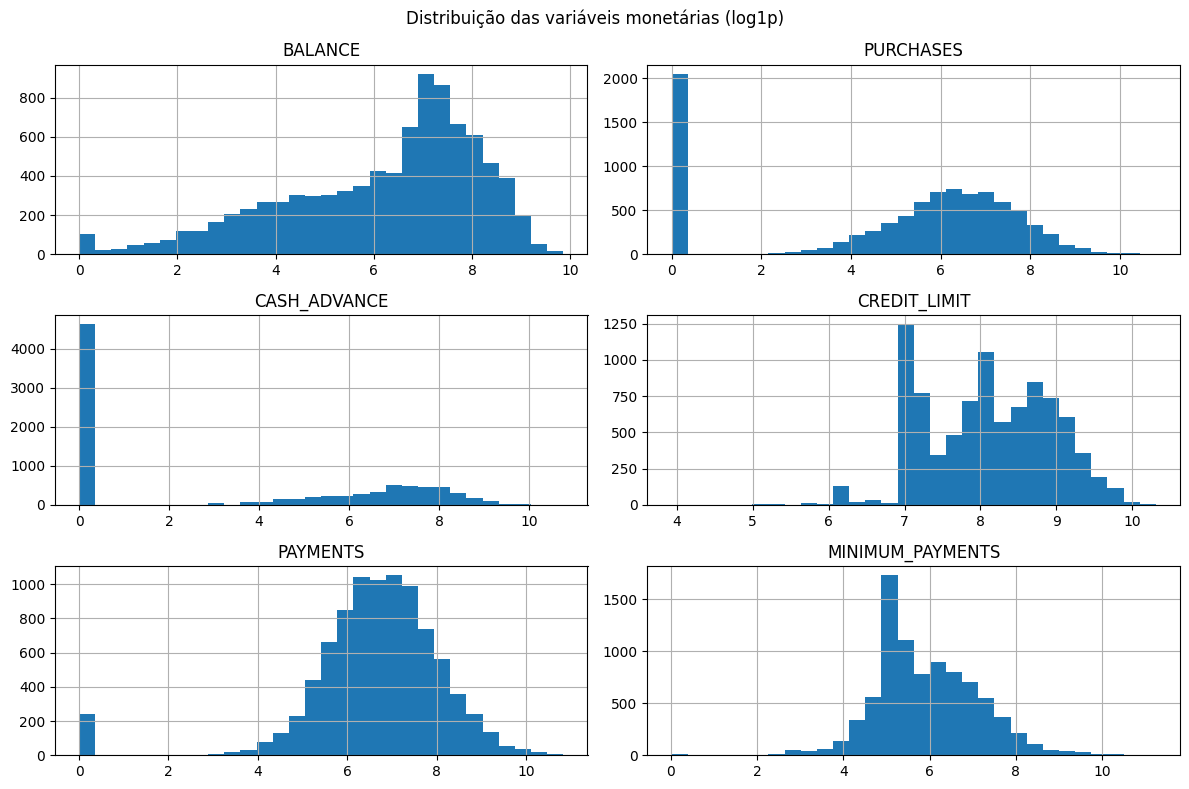

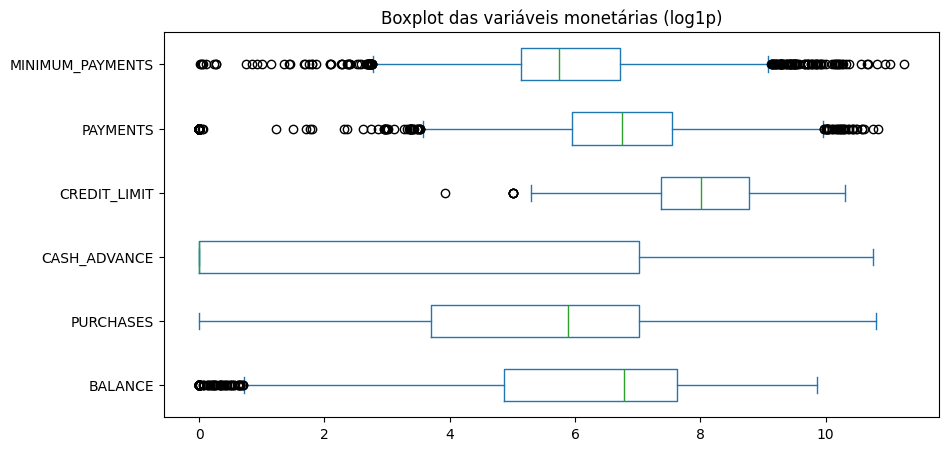

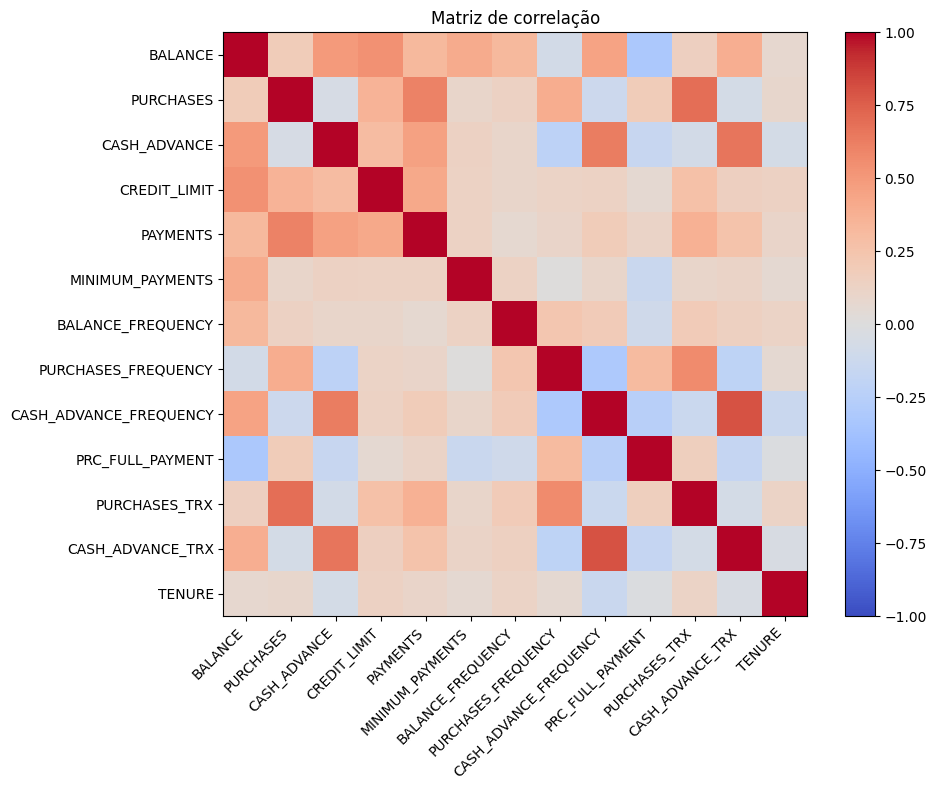

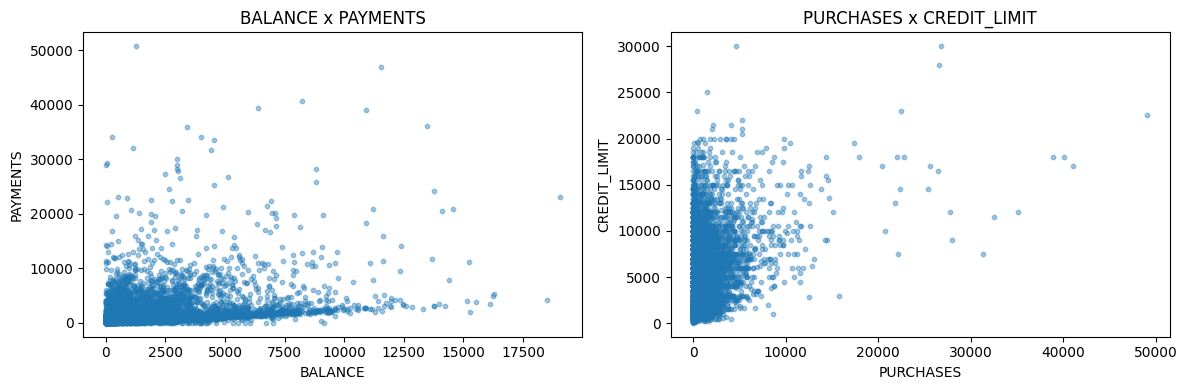

In [6]:
# Visualizações exploratórias básicas adaptadas ao dataset CC GENERAL

colunas_monetarias = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]
colunas_frequencia = ["BALANCE_FREQUENCY", "PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY", "PRC_FULL_PAYMENT"]
colunas_analise = colunas_monetarias + colunas_frequencia + ["PURCHASES_TRX", "CASH_ADVANCE_TRX", "TENURE"]

# 1. Valores ausentes
display(df.isna().sum().sort_values(ascending=False).head(10))

# 2. Distribuição das principais variáveis monetárias em escala logarítmica
df[colunas_monetarias].apply(np.log1p).hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribuição das variáveis monetárias (log1p)")
plt.tight_layout()
plt.show()

# 3. Boxplot para observar outliers
df[colunas_monetarias].apply(np.log1p).plot(kind="box", vert=False, figsize=(10, 5))
plt.title("Boxplot das variáveis monetárias (log1p)")
plt.show()

# 4. Correlação entre variáveis numéricas selecionadas
plt.figure(figsize=(10, 8))
corr = df[colunas_analise].corr()
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()

# 5. Relações simples entre variáveis importantes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["BALANCE"], df["PAYMENTS"], alpha=0.4, s=10)
axes[0].set_title("BALANCE x PAYMENTS")
axes[0].set_xlabel("BALANCE")
axes[0].set_ylabel("PAYMENTS")

axes[1].scatter(df["PURCHASES"], df["CREDIT_LIMIT"], alpha=0.4, s=10)
axes[1].set_title("PURCHASES x CREDIT_LIMIT")
axes[1].set_xlabel("PURCHASES")
axes[1].set_ylabel("CREDIT_LIMIT")

plt.tight_layout()
plt.show()


## 2.2 Análise visual — interpretação

As visualizações exploratórias indicam que as principais variáveis monetárias do dataset são bastante assimétricas. Mesmo após a aplicação de `log1p` nos histogramas, observa-se concentração de clientes em faixas menores de saldo, compras, saques e pagamentos, com uma quantidade menor de clientes apresentando valores muito altos. Esse padrão também aparece nas estatísticas descritivas: por exemplo, `PURCHASES` tem mediana de aproximadamente 361,28 e máximo de 49.039,57; `CASH_ADVANCE` tem mediana 0 e máximo de 47.137,21; `MINIMUM_PAYMENTS` tem mediana de aproximadamente 312,34 e máximo de 76.406,21.

Os boxplots em escala logarítmica reforçam a presença de valores extremos nas variáveis financeiras. Pelo critério de IQR, há outliers superiores em várias colunas relevantes: 695 em `BALANCE`, 808 em `PURCHASES`, 1.030 em `CASH_ADVANCE`, 808 em `PAYMENTS` e 841 em `MINIMUM_PAYMENTS`. Como esses valores podem representar clientes reais de alto gasto, alto endividamento ou uso intenso de saque, eles não devem ser removidos automaticamente.

A tabela de valores ausentes mostra que o problema de nulos é concentrado: `MINIMUM_PAYMENTS` possui 313 valores ausentes, cerca de 3,50% da base, e `CREDIT_LIMIT` possui apenas 1 valor ausente. Não há evidência de ausência generalizada nas demais variáveis. Portanto, a preparação deve tratar esses nulos sem descartar grande volume de dados.

A matriz de correlação sugere que algumas variáveis representam dimensões próximas do comportamento do cliente, como volume de compras, pagamentos e frequências de uso. Isso é importante para o K-Means porque variáveis correlacionadas ou em escalas muito diferentes podem influenciar excessivamente os centroides. Por isso, a modelagem deve usar transformação logarítmica nas variáveis monetárias e escalonamento antes do agrupamento.

Os gráficos de dispersão entre `BALANCE` e `PAYMENTS`, e entre `PURCHASES` e `CREDIT_LIMIT`, sugerem que há perfis variados: clientes com baixo movimento, clientes com compras compatíveis com limites maiores e clientes com valores financeiros muito acima da concentração principal. Essa variedade é justamente o que torna o agrupamento útil, mas também exige cuidado na interpretação para não rotular clientes vulneráveis de forma negativa.

Do ponto de vista das diretrizes de IA responsável, as visualizações mostram risco de uso indevido dos clusters. Combinações como alto `BALANCE`, alto `CASH_ADVANCE`, alto `MINIMUM_PAYMENTS` e baixo `PRC_FULL_PAYMENT` podem funcionar como proxies de vulnerabilidade financeira. Assim, os agrupamentos devem ser descritos como padrões comportamentais e não como julgamentos sobre valor, risco moral ou qualidade do cliente.


In [7]:
# Detecção simples de outliers em variáveis numéricas usando IQR
# Esta função é um exemplo. O grupo deve avaliar se o critério faz sentido para cada atributo.

def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

# Exemplo de uso:
# outliers = detectar_outliers_iqr(df, "[COLUNA_NUMERICA]")
# display(outliers.head())


## 2.3 Problemas de qualidade dos dados

| Problema identificado | Evidência | Decisão tomada | Justificativa |
|---|---|---|---|
| Valores ausentes em `MINIMUM_PAYMENTS` | 313 valores ausentes, cerca de 3,50% da base. | Imputar com mediana na etapa de modelagem. | O K-Means não aceita valores nulos. A mediana é mais robusta que a média em uma variável muito assimétrica, mas a decisão deve ser registrada porque nulo em pagamento mínimo pode ter significado financeiro. |
| Valor ausente em `CREDIT_LIMIT` | 1 valor ausente, cerca de 0,01% da base. | Imputar com mediana. | Como há apenas um caso, a imputação evita perder uma linha inteira e tem impacto baixo sobre a distribuição geral. |
| Duplicatas | `df.duplicated().sum()` retornou 0. | Não remover registros por duplicidade. | Não há duplicatas exatas detectadas, então nenhuma ação é necessária nesse ponto. |
| Outliers em variáveis monetárias | Pelo critério de IQR: 695 outliers superiores em `BALANCE`, 808 em `PURCHASES`, 1.030 em `CASH_ADVANCE`, 808 em `PAYMENTS` e 841 em `MINIMUM_PAYMENTS`. | Não remover automaticamente; aplicar `log1p` e escalonamento robusto. | Em dados financeiros, valores extremos podem ser clientes reais e relevantes. Removê-los poderia distorcer a segmentação e invisibilizar perfis importantes. |
| Escalas muito diferentes | Variáveis monetárias chegam a dezenas de milhares, enquanto frequências como `PURCHASES_FREQUENCY` e `PRC_FULL_PAYMENT` variam entre 0 e 1. | Aplicar escalonamento antes do K-Means. | O K-Means depende de distância; sem escalonamento, as variáveis monetárias dominariam os agrupamentos. |
| Variável identificadora `CUST_ID` | A coluna possui 8.950 valores únicos em 8.950 registros. | Remover antes da modelagem. | `CUST_ID` não representa comportamento financeiro e pode introduzir ruído ou risco de reidentificação. |
| Variáveis categóricas | A única coluna não numérica é `CUST_ID`. | Não aplicar codificação categórica. | Após remover `CUST_ID`, o conjunto utilizado na modelagem fica composto por variáveis numéricas. |
| Possíveis proxies de vulnerabilidade financeira | Variáveis como `BALANCE`, `CASH_ADVANCE`, `MINIMUM_PAYMENTS`, `CREDIT_LIMIT` e `PRC_FULL_PAYMENT` podem indicar capacidade de pagamento, uso de crédito emergencial e endividamento. | Manter para análise, mas interpretar com cautela. | Essas variáveis são úteis para segmentação, porém não devem sustentar rótulos estigmatizantes ou decisões excludentes sem análise adicional. |

### Observação sobre responsabilidade

A principal implicação ética da preparação está no equilíbrio entre utilidade analítica e risco de perfilamento. Remover `CUST_ID` reduz ruído e risco de identificação, mas manter variáveis financeiras sensíveis exige cuidado na interpretação posterior. O grupo opta por preservar variáveis comportamentais importantes para o agrupamento, desde que os clusters sejam descritos de forma neutra e usados como apoio analítico, não como base automática para excluir clientes, negar benefícios ou direcionar ações predatórias.

A decisão de não remover outliers também tem impacto responsável. Clientes com valores extremos podem representar perfis legítimos, como usuários de alto limite, clientes com grande volume de compras ou pessoas em situação de maior dependência de crédito. A preparação adotada deve reduzir o efeito desses valores sobre o K-Means sem apagá-los da base.


In [8]:
# Exemplo de preparação dos dados
# Esta célula é propositalmente genérica.
# O grupo deve adaptar de acordo com o dataset e a tarefa.

def preparar_dados_basico(
    df: pd.DataFrame,
    colunas_remover=None,
    imputar_numericas=True,
    imputar_categoricas=True
) -> pd.DataFrame:
    df_prep = df.copy()

    # 1. Remover duplicatas exatas
    df_prep = df_prep.drop_duplicates()

    # 2. Remover colunas explicitamente marcadas como irrelevantes ou identificadoras
    if colunas_remover is None:
        colunas_remover = [
            # "[INSERIR_COLUNA_IDENTIFICADORA]",
            # "[INSERIR_COLUNA_IRRELEVANTE]",
        ]

    colunas_existentes = [col for col in colunas_remover if col in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_existentes)

    # 3. Exemplo de tratamento simples de nulos
    # Atenção: imputação deve ser justificada no texto.
    if imputar_numericas:
        for col in df_prep.select_dtypes(include=np.number).columns:
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    if imputar_categoricas:
        for col in df_prep.select_dtypes(include=["object", "category"]).columns:
            df_prep[col] = df_prep[col].fillna("desconhecido")

    return df_prep

# Exemplo de uso:
# df_prep = preparar_dados_basico(df, colunas_remover=["id"])
# display(df_prep.head())


## 2.4 Justificativa da preparação dos dados

A preparação dos dados foi definida considerando a tarefa de agrupamento com K-Means. Como o algoritmo calcula distâncias entre clientes, qualquer coluna irrelevante, escala desbalanceada, valor ausente ou outlier extremo pode alterar diretamente a posição dos centroides e, portanto, a formação dos clusters.

A coluna `CUST_ID` deve ser removida antes da modelagem. Embora seja útil para rastrear registros na base original, ela é um identificador mascarado, possui 8.950 valores únicos e não descreve comportamento financeiro. Mantê-la no modelo não acrescentaria informação relevante para agrupamento e poderia aumentar risco de reidentificação ou ruído metodológico.

Os valores ausentes serão tratados por imputação pela mediana nas variáveis numéricas. Essa decisão é especialmente importante para `MINIMUM_PAYMENTS`, que possui 313 nulos, e para `CREDIT_LIMIT`, que possui 1 nulo. A mediana foi escolhida porque as variáveis financeiras são assimétricas e possuem valores extremos; nesse cenário, a média poderia ser puxada por clientes com valores muito altos. A imputação permite executar o K-Means sem descartar registros, mas introduz o risco de suavizar diferenças reais entre clientes. Por isso, essa decisão deve ser documentada e considerada na interpretação dos clusters.

Como a única variável categórica é `CUST_ID`, não será necessário aplicar codificação como one-hot encoding. Após sua remoção, o conjunto de modelagem fica composto por atributos numéricos. Isso simplifica o pipeline e evita criar dimensões artificiais sem significado comportamental.

As variáveis monetárias serão transformadas com `log1p`, pois os histogramas, boxplots e estatísticas descritivas mostram forte assimetria e valores extremos. Essa transformação reduz a influência da cauda longa sem excluir clientes da análise. O grupo opta por não remover outliers automaticamente, pois em uma base bancária eles podem representar perfis legítimos, como clientes de alto limite, alto volume de compras, alto saldo ou uso intenso de saque em dinheiro.

Depois da transformação, será aplicado escalonamento antes do K-Means. Essa etapa é obrigatória porque variáveis como `CREDIT_LIMIT`, `PAYMENTS` e `PURCHASES` podem chegar a dezenas de milhares, enquanto variáveis de frequência variam entre 0 e 1. Sem escalonamento, o agrupamento seria dominado pelas variáveis monetárias. Para a modelagem preliminar, o `RobustScaler` é adequado por ser menos sensível a outliers, usando mediana e intervalo interquartil.

Também serão criadas variáveis derivadas simples para apoiar a interpretação dos perfis, como utilização do limite, razão entre pagamento e pagamento mínimo, e razão entre saque e compras. Essas variáveis ajudam a aproximar a modelagem de conceitos de negócio, mas precisam ser suavizadas com corte de extremos e `log1p`, pois razões financeiras podem gerar valores muito altos quando o denominador é pequeno.

Essas decisões se relacionam diretamente às diretrizes escolhidas. A remoção de `CUST_ID` atende à minimização de dados; a não remoção automática de outliers evita excluir perfis legítimos; e o escalonamento reduz o risco de que apenas clientes com valores monetários altos determinem a segmentação. Ao mesmo tempo, variáveis financeiras podem funcionar como proxies de vulnerabilidade. Por isso, a etapa de preparação não elimina a necessidade de interpretar os clusters com cautela e evitar rótulos ou decisões que punam clientes por sinais de endividamento.


## 2.5 Interações com LLM — Data Understanding & Data Preparation

### Subtarefa comparável

Nesta etapa, as duas trilhas devem receber a mesma subtarefa geral.

**Subtarefa escolhida:** [EXEMPLO: propor estratégias de limpeza, transformação e preparação dos dados para a tarefa de mineração]

---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 23/05/2026  
**Link da conversa:** [\[INSERIR LINK DA CONVERSA\]](https://gemini.google.com/share/c0b2d5f99d84)

#### Prompt principal — baseline

```text
Tenho um dataset de cartões de crédito (CC GENERAL) com as seguintes colunas: CUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PR_FULL_PAYMENT, TENURE.

A tarefa de mineração é aplicar o algoritmo K-Means para realizar o agrupamento (Clustering) e segmentação dos perfis de comportamento financeiro dos clientes.

Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa.
```

#### Síntese da resposta da LLM

1. Data Understanding (Entendimento dos Dados)Antes de transformar, você precisa conhecer as armadilhas do dataset. Olhando para a sua lista de colunas, três verificações são críticas:Identificadores Únicos: A coluna CUST_ID é apenas um texto identificador. Ela deve ser removida antes do treino, ou definida como o índice do DataFrame (df.set_index('CUST_ID')), senão o K-Means tentará usá-la no cálculo de distância.Análise de Escala: Variáveis como BALANCE e CREDIT_LIMIT estão na casa dos milhares (ex: $5000$). Variáveis como PURCHASES_FREQUENCY estão entre $0$ e $1$. Se você não normalizar, o K-Means vai ignorar as frequências e focar apenas nos valores monetários.Valores Ausentes: Este dataset historicamente possui duas colunas com dados faltantes que precisam de atenção: MINIMUM_PAYMENTS e CREDIT_LIMIT.

2. Data Preparation (Preparação dos Dados)
Aqui está a sequência lógica de passos para tratar o dataset, com exemplos de código em Python usando Pandas e Scikit-Learn:

Passo 1: Tratamento de Valores Ausentes (Imputação)O K-Means não aceita NaNs.CREDIT_LIMIT: Geralmente tem pouquíssimos nulos. Substituir pela mediana é seguro.MINIMUM_PAYMENTS: Tem muitos nulos. Isso acontece porque clientes que não usam o cartão ou pagam a fatura antes do fechamento não geram pagamento mínimo. Substituir pela mediana ou por 0 (se o saldo devedor for zero) são boas abordagens.Pythonimport pandas as pd

Passo 2: Engenharia de Atributos (Feature Engineering)Para o K-Means extrair perfis de comportamento ricos, criar variáveis que consolidam o comportamento do cliente ajuda muito o algoritmo. Recomendo criar estas três:

3. Pagamento Efetivo: Relação entre o que ele pagou e o mínimo exigido

Passo 3: Tratamento de Outliers (Assimetria)Dados financeiros de cartão de crédito são altamente assimétricos (pouquíssimos clientes gastam milhões, enquanto a maioria gasta pouco). O K-Means sofre com isso porque os clientes "super-ricos" puxam os centros dos clusters para longe.A melhor estratégia aqui é aplicar uma transformação logarítmica nas colunas financeiras (valores em dinheiro) para suavizar a cauda longa dos outliers, em vez de simplesmente deletar os clientes mais valiosos da base.

Passo 4: Padronização (Scaling)Por fim, aplique o StandardScaler para garantir que todas as variáveis (tanto as de dinheiro transformadas em log quanto as de frequência entre 0 e 1) tenham média 0 e desvio padrão 1.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 23/05/2026
**Link da conversa:** (https://gemini.google.com/share/f2dcb4fbfbd1)

#### Prompt principal — guiado

```text
Tenho um dataset de cartões de crédito (CC GENERAL) com as seguintes colunas: CUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PR_FULL_PAYMENT, TENURE.

A tarefa de mineração é aplicar o algoritmo K-Means para agrupar e segmentar os clientes com base em seus comportamentos de consumo e crédito.

Sugira uma estratégia de Data Understanding e Data Preparation.

Considere explicitamente as diretrizes de IA Responsável:
1. Minimização de Dados e Utilidade: Avalie o impacto de remover o identificador CUST_ID e como garantir que variáveis com ordens de grandeza muito diferentes (como limites de crédito de milhares de dólares vs. frequências de compra entre 0 e 1) colaborem de forma justa no cálculo das distâncias do K-Means.
2. Impacto de Decisões Automatizadas no Perfilamento: Discuta como a escolha de tratamento de outliers extremos (comuns em dados bancários) pode excluir ou invisibilizar perfis de clientes legítimos da estratégia final de negócios.

Ao sugerir a preparação, indique detalhadamente:
- possíveis atributos sensíveis (ou proxies de vulnerabilidade financeira, como a relação entre saldo devedor e pagamento mínimo);
- riscos de viés metodológico ou distorção dos centroides caso os dados não sejam padronizados corretamente;
- decisões de design dos dados que devem ser formalmente documentadas pelo grupo (ex: escolha entre StandardScaler ou RobustScaler);
- transformações necessárias (tratamento de valores nulos em MINIMUM_PAYMENTS e CREDIT_LIMIT, além de técnicas de redução de dimensionalidade como PCA, se aplicável);
- limitações estatísticas e os trade-offs do K-Means (como a necessidade de definir o número K previamente e a suposição de clusters esféricos).
```

#### Síntese da resposta da LLM

1. Data Understanding e Diretrizes de IA Responsável
- Minimização de Dados: Remover a variável CUST_ID, pois não possui valor analítico e pode comprometer a privacidade; A remoção reduz risco de reidentificação e evita ruídos nos agrupamentos.
- Variáveis Sensíveis: Combinações como CASH_ADVANCE, PRC_FULL_PAYMENT, MINIMUM_PAYMENTS, BALANCE e CREDIT_LIMIT podem indicar vulnerabilidade financeira; Esses perfis devem ser usados para apoio (renegociação, auxílio) e não para práticas predatórias.

2. Data Preparation: Transformações e Decisões
- A. Valores Nulos: 
CREDIT_LIMIT: poucos casos → remover linha ou preencher com a mediana.
MINIMUM_PAYMENTS: analisar a origem dos nulos antes de imputar (0, mediana ou KNN).
- B. Outliers: 
Não excluir valores extremos, pois podem representar clientes reais importantes.
Aplicar transformação logarítmica (log1p) para reduzir assimetrias sem perder dados.
- C. Padronização: 
Necessária para evitar que variáveis monetárias dominem o K-Means.
Preferir RobustScaler, por ser menos sensível a outliers que o StandardScaler.
- D. Redução de Dimensionalidade (PCA): 
Aplicar PCA para reduzir correlação entre variáveis e facilitar visualização.
Desvantagem: reduz a interpretabilidade dos resultados.

3. Limitações e Trade-offs do K-Means
- Clusters esféricos: o algoritmo assume grupos homogêneos, o que nem sempre ocorre em dados financeiros.
- Definição do K: usar Método do Cotovelo e Silhouette Score, considerando também a viabilidade para o negócio.
- Sensibilidade ao ruído: todos os pontos são forçados a um cluster, podendo distorcer os perfis gerados.


## 2.6 Comparação crítica — Data Understanding & Preparation

| Aspecto | Trilha A — baseline | Trilha B — guiada | Decisão do grupo |
|---|---|---|---|
| Tratamento de nulos | Identificou `MINIMUM_PAYMENTS` e `CREDIT_LIMIT` como colunas críticas e sugeriu imputação por mediana ou zero em alguns casos. | Reforçou a necessidade de analisar a origem dos nulos antes de imputar, especialmente em `MINIMUM_PAYMENTS`. | Aceitar parcialmente: usar mediana para manter o pipeline simples, mas registrar que a imputação pode esconder diferenças entre clientes sem fatura mínima observada e clientes com pagamentos baixos. |
| Tratamento de outliers | Sugeriu transformação logarítmica nas variáveis monetárias em vez de excluir clientes extremos. | Também recomendou `log1p`, mas destacou que excluir extremos pode invisibilizar perfis reais e relevantes. | Aceitar: aplicar `log1p` nas variáveis monetárias e evitar remoção automática de outliers. |
| Atributos sensíveis | Não discutiu de forma suficiente atributos sensíveis ou proxies. | Indicou proxies de vulnerabilidade financeira, como alto `BALANCE`, alto `CASH_ADVANCE`, baixo `PRC_FULL_PAYMENT` e relação com `MINIMUM_PAYMENTS`. | Corrigir com cuidado: o dataset não tem atributos sensíveis diretos, mas os clusters devem ser interpretados sem rótulos estigmatizantes ou uso punitivo. |
| Codificação de variáveis | Indicou remover ou indexar `CUST_ID` e padronizar as variáveis numéricas. | Reforçou minimização de dados, remoção de `CUST_ID` e escolha documentada do scaler. | Aceitar: remover `CUST_ID`; como as demais variáveis são numéricas, não há necessidade de one-hot encoding. |
| Redução de dimensionalidade | Não detalhou PCA como etapa central. | Sugeriu PCA para visualização e possível redução de correlação, com perda de interpretabilidade. | Aceitar apenas para análise visual e apoio diagnóstico; não usar PCA como única base de interpretação dos clusters. |
| Justificativa técnica | Explicou bem a dependência do K-Means em escala e distância, mas deixou a engenharia de atributos incompleta. | Apresentou melhor relação entre preparação, robustez e riscos de interpretação. | Combinar as duas: manter a preparação simples, escalonada e documentada, com transformação logarítmica e avaliação posterior dos clusters. |
| Riscos e limitações | Mencionou assimetria e domínio das variáveis monetárias, mas pouco sobre impactos de negócio. | Discutiu distorção de centroides, outliers, proxies de vulnerabilidade e limitações do K-Means. | Priorizar a Trilha B para os riscos; complementar com evidências do notebook antes de tomar decisões finais. |

### Análise crítica

As duas trilhas acertaram ao apontar que o K-Means exige preparação cuidadosa, pois o algoritmo calcula distância entre pontos. Sem padronização, variáveis monetárias como `BALANCE`, `PURCHASES`, `CREDIT_LIMIT`, `PAYMENTS` e `MINIMUM_PAYMENTS` dominariam variáveis de frequência que variam entre 0 e 1. Também foi correta a recomendação de remover `CUST_ID`, já que se trata de um identificador e não de um atributo comportamental.

A Trilha A foi útil para montar uma sequência técnica básica: remover identificador, tratar nulos, suavizar assimetria com `log1p` e aplicar scaler antes do K-Means. Porém, ela ficou incompleta ao tratar os nulos de forma muito automática e ao mencionar engenharia de atributos sem detalhar completamente quais variáveis seriam criadas e como seriam validadas. A sugestão de imputar `MINIMUM_PAYMENTS` com mediana ou zero precisa de justificativa, pois essa ausência pode ter significado financeiro diferente dependendo do perfil do cliente.

A Trilha B apresentou uma análise mais adequada para o contexto do trabalho porque relacionou as decisões de preparação com riscos de IA responsável. Em especial, destacou que outliers em dados bancários não são necessariamente erros: podem representar clientes reais, de alto gasto, alto limite ou alto endividamento. Por isso, o grupo aceita a transformação logarítmica, mas rejeita a remoção automática de valores extremos apenas por regra estatística.

O grupo também aceita a recomendação de documentar a escolha do scaler. Como há muitos valores extremos, `RobustScaler` é uma opção mais coerente que `StandardScaler` para os primeiros testes, pois usa mediana e intervalo interquartil. Ainda assim, essa escolha deve ser avaliada empiricamente nas métricas de agrupamento e na interpretação dos perfis.

Por fim, a Trilha B foi mais forte ao discutir proxies de vulnerabilidade financeira. O grupo não irá remover automaticamente variáveis como `CASH_ADVANCE`, `MINIMUM_PAYMENTS` ou `PRC_FULL_PAYMENT`, porque elas são importantes para compreender comportamento financeiro. A correção adotada é usá-las com cautela: os clusters devem receber descrições comportamentais neutras e não rótulos como "maus pagadores" ou "clientes problemáticos".


# 3. Modeling

Nesta seção, o grupo deve documentar a modelagem proposta com apoio da LLM.

Para o TP de padrões frequentes, a modelagem pode envolver, por exemplo:

- Apriori;
- FP-Growth;
- Eclat;
- regras de associação.

Para outros TPs, substituir pelos algoritmos pertinentes, como algoritmos de agrupamento ou classificação.

O foco da Fase 2 é comparar criticamente as soluções sugeridas pela LLM nas duas trilhas e, quando possível, executar testes preliminares para verificar a viabilidade das sugestões.


## 3.1 Interações com LLM — Modeling

### Subtarefa comparável

**Subtarefa escolhida:** [EXEMPLO: propor algoritmos, parâmetros, métricas e estratégia de avaliação para a tarefa]

---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 23/05/2026
**Link da conversa:** [INSERIR LINK DA CONVERSA]

#### Prompt principal — baseline

```text
Com base no dataset CC GENERAL e na tarefa de agrupamento com o algoritmo K-Means, proponha uma estratégia de modelagem.

Indique os algoritmos e abordagens necessárias para definir o número ideal de clusters (K), sugestões de parâmetros iniciais (como o método de inicialização dos centroides), métricas de avaliação interna para validar a qualidade dos agrupamentos e como o grupo deve comparar e interpretar os resultados obtnar.
```

#### Síntese da resposta da LLM

1. Algoritmos e Escolha do Número Ideal de Clusters ($K$)Para definir o valor de $K$ sem cair no subjetivismo, o grupo deve combinar duas abordagens complementares (uma geométrica e uma probabilística/silhueta):
A. Método do Cotovelo (Elbow Method) com WCSSO algoritmo calcula a Soma dos Quadrados Intra-Cluster (WCSS - Within-Cluster Sum of Squares), que mede a distância de cada ponto em relação ao centroide do seu cluster.
Abordagem: Plote um gráfico de linha com o número de clusters no eixo X (recomendo testar de $K=2$ a $K=10$) e o WCSS no eixo Y.
Critério de Escolha: O número ideal é o ponto de inflexão da curva (o "cotovelo"), onde adicionar mais um cluster deixa de trazer um ganho expressivo na redução da variância interna.
B. Análise de Silhueta (Silhouette Score)Enquanto o Cotovelo olha apenas para dentro, a Silhueta avalia o equilíbrio. O coeficiente de silhueta de um ponto mede o quão sutilmente ele pertence ao seu cluster atual em comparação com o cluster vizinho mais próximo. A métrica varia de $-1$ a $+1$.
Abordagem: Calcule a média do Silhouette Score para cada valor de $K$.
Critério de Escolha: Busque o $K$ que maximiza o score médio geral (valores mais próximos de $1$), garantindo também que os clusters individuais tenham espessuras de silhueta equilibradas (sem clusters gigantes com scores ruins e clusters minúsculos com scores ótimos).

2. Parâmetros Iniciais Recomendados para o K-MeansAo instanciar o K-Means (por exemplo, utilizando a biblioteca scikit-learn), configure os parâmetros para mitigar os problemas clássicos de convergência do algoritmo:n_clusters=K: Definido pelas técnicas do passo anterior (geralmente para o CC GENERAL, os melhores resultados de negócio oscilam entre $K=3$ e $K=5$).init='k-means++': Fundamental. Em vez de escolher os primeiros centroides de forma totalmente aleatória (o que pode fazer o algoritmo convergir para soluções ruins), o k-means++ espalha os centroides iniciais longe uns dos outros de forma inteligente, acelerando a convergência e garantindo estabilidade.n_init=10 ou 20: Força o algoritmo a rodar 10 a 20 vezes independentes com sementes iniciais diferentes, escolhendo ao final a execução que gerou o menor WCSS.max_iter=300: O número máximo de iterações em uma única corrida para ajustar a posição dos centroides.random_state=42: Fixa a semente de aleatoriedade para garantir a reprodutibilidade do experimento pelo grupo.

3. Métricas de Avaliação InternaComo estamos lidando com aprendizado não supervisionado (não temos um "gabarito" ou rótulo real na base), devemos usar métricas intrínsecas:Coeficiente de Silhueta Médio: Avalia se os grupos estão bem separados entre si e compactos internamente.Índice Calinski-Harabasz (Variance Ratio Criterion): Mede a razão entre a dispersão entre os clusters e a dispersão dentro do cluster. Quanto maior o valor, mais nítidos e bem definidos são os agrupamentos.Índice Davies-Bouldin: Avalia a similaridade entre os clusters (com base na distância dos centroides e no tamanho dos clusters). Ao contrário dos outros, valores menores indicam uma melhor separação.

4. Comparação e Interpretação dos ResultadosA validação estatística não basta; o grupo precisa validar a utilidade prática dos grupos. Sigam este roteiro para comparar e interpreta
---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 23/05/2026
**Link da conversa:** https://gemini.google.com/share/0d13fb787f6f

#### Prompt principal — guiado

```text
Com base no dataset CC GENERAL e na tarefa de agrupamento com o algoritmo K-Means, proponha uma estratégia de modelagem.

Considere explicitamente as diretrizes de IA Responsável:
1. Interpretabilidade e Explicabilidade dos Agrupamentos: Como o K-Means agrupa os dados puramente por distância matemática, garanta que a definição e a caracterização final de cada cluster (ex: 'Clientes com alto endividamento') sejam explicáveis e fáceis de auditar, evitando rotulagens arbitrárias que gerem estigma aos clientes.
2. Robustez Metodológica e Reprodutibilidade: Discuta a importância da escolha da semente de inicialização (random_state) e do método de escolha dos centroides iniciais (como o k-means++) para assegurar que os agrupamentos gerados sejam estáveis e não mudem drasticamente a cada execução do modelo.

Na resposta, indique detalhadamente:
- algoritmos e métodos adequados para a modelagem e definição do número ideal de grupos (como o Método do Cotovelo e o Gráfico de Silhueta);
- parâmetros iniciais recomendados (n_init, max_iter, init);
- métricas de avaliação interna da qualidade dos clusters (Inércia e Coeficiente de Silhueta);
- riscos metodológicos comuns ao aplicar K-Means em dados bancários reais (como a convergência para mínimos locais devido à sensibilidade a outliers);
- impacto das diretrizes de IA responsável nas escolhas de modelagem (por exemplo, como limitar o número de variáveis ou aplicar PCA para manter os clusters interpretáveis);
- trade-offs entre o desempenho métrico do modelo, a interpretabilidade dos clusters pelo time de negócios, o custo computacional e a qualidade humana da solução gerada.
```

#### Síntese da resposta da LLM

1. Robustez Metodológica e Reprodutibilidade

Para garantir estabilidade e evitar resultados inconsistentes:

- k-means++: melhora a escolha inicial dos centroides e reduz mínimos locais.
- random_state fixo: garante reprodutibilidade dos resultados.
- n_init ≥ 10: executa múltiplas inicializações e escolhe a melhor solução.
- max_iter = 300: limite adequado para convergência.


2. Definição do Número Ideal de Grupos (K)

A escolha do número de clusters deve usar métricas de avaliação:

- Inércia: mede a coesão dos grupos; usar o Método do Cotovelo para encontrar o K ideal.
- Silhouette Score: avalia coesão e separação dos clusters; ajuda a identificar grupos equilibrados.


3. Interpretabilidade e IA Responsável
- Explicabilidade: 
Após aplicar PCA, associar os clusters ao dataset original para interpretar resultados.
Calcular médias e medianas por cluster para facilitar a análise.
- Rotulagem ética: 
Evitar rótulos estigmatizantes.
Priorizar nomes baseados em comportamento, como "Usuários Intensivos de Saque" ou "Pagadores Rotativos".


4. Riscos Metodológicos
- Outliers: valores extremos podem distorcer centroides e criar clusters inadequados.
- Clusters esféricos: K-Means assume formatos homogêneos, o que nem sempre ocorre em dados financeiros.


5. Trade-offs da Solução
- Desempenho vs. Negócio: o melhor K matemático pode não ser o mais útil para marketing.
- Interpretabilidade vs. Eficiência: PCA melhora desempenho, mas reduz explicabilidade.
- Lucro vs. Ética: evitar estratégias lucrativas que explorem clientes vulneráveis.


## 3.2 Comparação das soluções sugeridas pela LLM

| Elemento | Trilha A — baseline | Trilha B — guiada | Diferença concreta? | Comentário do grupo |
|---|---|---|---|---|
| Algoritmos sugeridos | K-Means como algoritmo principal, com análise do número de clusters por cotovelo e silhueta. | K-Means como principal, com possibilidade de PCA para visualização e atenção à estabilidade. | Parcialmente | As duas trilhas convergem no K-Means, que é adequado ao objetivo do TP. A Trilha B melhora a discussão sobre estabilidade e explicabilidade. |
| Parâmetros sugeridos | Uso de `k-means++`, `random_state`, `n_init` e `max_iter`, mas com pouca discussão crítica. | Recomenda `init="k-means++"`, `random_state=42`, `n_init >= 10` e `max_iter=300`. | Sim | A Trilha B é mais completa porque associa parâmetros à reprodutibilidade e à redução de mínimos locais. |
| Métricas sugeridas | Inércia pelo método do cotovelo e Silhouette Score. | Inércia, Silhouette Score e análise substantiva dos grupos; menciona limites das métricas. | Sim | As métricas internas são necessárias, mas não suficientes. A interpretação dos centroides e tamanhos dos grupos também deve orientar a decisão. |
| Preparação exigida | Padronização após tratamento de nulos e transformação logarítmica. | Reforça imputação documentada, `log1p`, escolha entre `StandardScaler` e `RobustScaler`, e eventual PCA. | Sim | A preparação da Trilha B é mais alinhada ao dataset, pois considera outliers e assimetria financeira. |
| Interpretabilidade | Sugere comparar e interpretar os resultados, mas de modo genérico. | Propõe calcular médias/medianas por cluster e evitar rótulos arbitrários ou estigmatizantes. | Sim | A Trilha B atende melhor à necessidade de explicar clusters para uso de negócio sem transformar agrupamentos em julgamentos sobre clientes. |
| Custo computacional | Baixo a moderado; K-Means é eficiente para aproximadamente 9 mil registros. | Também baixo a moderado, mas aumenta se forem testados muitos valores de K, várias inicializações e PCA. | Parcialmente | O custo é aceitável para o tamanho do dataset. O uso de `n_init` e varredura de K aumenta o tempo, mas melhora robustez. |
| Riscos ou limitações | Menciona sensibilidade a escala e outliers. | Detalha mínimos locais, clusters esféricos, sensibilidade a outliers, escolha prévia de K e risco de rótulos inadequados. | Sim | A Trilha B é mais útil para registrar limitações metodológicas do K-Means em dados financeiros. |
| Aderência às diretrizes | Baixa a moderada; foca mais no funcionamento técnico. | Alta; relaciona modelagem com interpretabilidade, robustez, reprodutibilidade e impacto dos perfis. | Sim | A resposta guiada não substitui validação empírica, mas gera critérios mais claros para uma solução responsável. |

### Síntese

As duas soluções recomendam K-Means, o que está alinhado com a tarefa definida para o TP. A diferença principal é que a Trilha A descreve uma estratégia técnica mínima, enquanto a Trilha B transforma essa estratégia em um processo mais auditável: define parâmetros reprodutíveis, propõe avaliar diferentes valores de K e exige interpretação cuidadosa dos clusters.

O grupo aceita usar `k-means++`, `random_state=42`, `n_init=10` e `max_iter=300` como configuração inicial. A escolha do número de clusters não será feita apenas pela menor inércia, pois a inércia sempre tende a diminuir quando K aumenta. Por isso, a decisão deve combinar método do cotovelo, Silhouette Score, Davies-Bouldin, tamanho dos grupos e capacidade de explicar os perfis formados.

A Trilha B também é superior na discussão de interpretabilidade. Para este dataset, não basta dizer que um cluster tem alta média em determinada variável; é necessário verificar medianas, proporções e combinações de comportamento, como alto uso de saque, alta frequência de compra, baixo pagamento integral ou alto uso do limite. A interpretação final deve ser neutra e baseada em comportamento observado.

Como limitação, nenhuma das trilhas resolve sozinha a validação externa dos clusters, pois o dataset não possui rótulos verdadeiros. Assim, a solução adotada será preliminar: gerar agrupamentos, avaliar métricas internas e produzir perfis descritivos, deixando claro que os clusters não devem ser usados automaticamente para decisões de crédito, exclusão de benefícios ou campanhas predatórias.


## 3.4 Modelagem para agrupamento com K-Means

Nesta subseção, o template genérico foi adaptado para o dataset CC GENERAL. A modelagem considera que o objetivo é segmentar clientes por comportamento financeiro usando K-Means.

Como não há rótulo verdadeiro, a avaliação combina métricas internas, comparação entre valores de K e interpretação substantiva dos grupos. A preparação inclui remoção de `CUST_ID`, imputação simples dos nulos, transformação `log1p` nas variáveis monetárias e escalonamento robusto para reduzir o efeito de valores extremos.


,k,inercia,silhouette,davies_bouldin
0,2,170288.258264,0.290561,1.747297
1,3,139740.726318,0.326026,1.235461
2,4,117005.150730,0.253598,1.350889
3,5,105689.186390,0.247879,1.282966
4,6,95360.911680,0.257023,1.227870
5,7,86615.330886,0.266663,1.142827
6,8,81839.829025,0.233972,1.276990


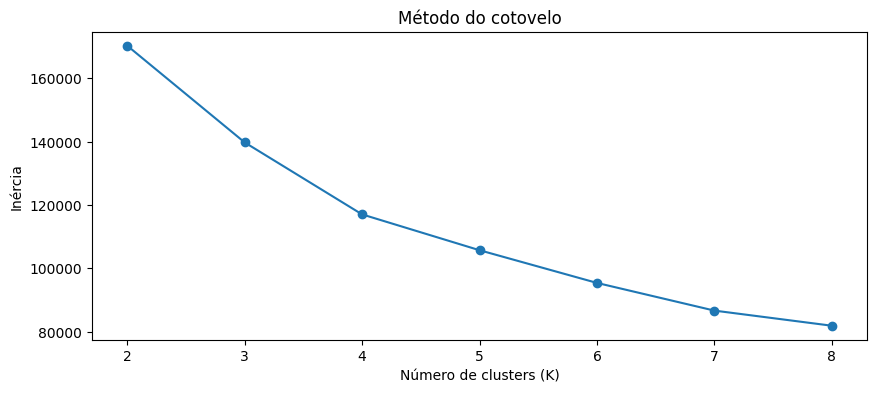

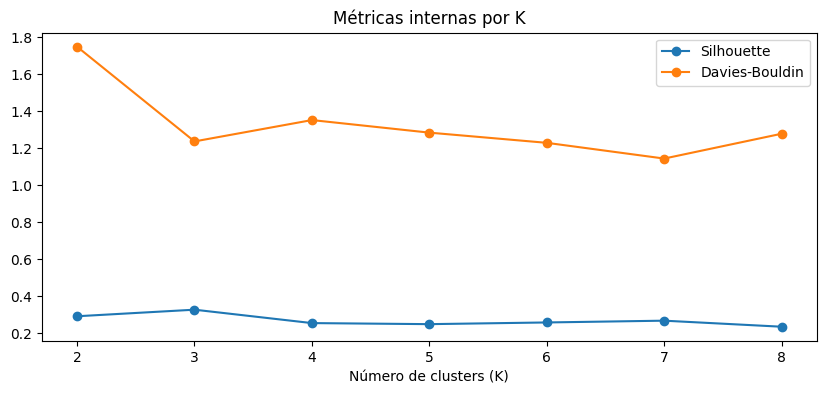

cluster
0    3934
1    2574
2    1208
3    1234
Name: quantidade_clientes, dtype: int64

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,UTILIZACAO_LIMITE,RAZAO_PAGAMENTO_MINIMO,RAZAO_SAQUE_COMPRA
cluster,,,,,,,,,,,,,,,,,,,,
0,6.96,1.00,6.61,5.71,5.63,0.00,0.83,0.17,0.50,0.00,0.0,12.0,8.01,6.79,5.97,0.00,12.0,0.30,1.00,0.00
1,7.56,1.00,0.00,0.00,0.00,7.43,0.00,0.00,0.00,0.33,6.0,0.0,8.01,6.89,6.44,0.00,12.0,0.52,0.74,6.12
2,3.22,0.36,4.94,0.00,0.00,0.00,0.17,0.00,0.00,0.00,0.0,2.0,7.90,5.79,4.84,0.00,12.0,0.01,1.43,0.00
3,4.52,1.00,6.84,4.69,6.13,0.00,0.92,0.08,0.75,0.00,0.0,14.0,8.29,7.00,5.11,0.85,12.0,0.02,2.10,0.00


In [9]:
# Pipeline adaptado ao dataset CC GENERAL para agrupamento com K-Means

def preparar_dados_kmeans_cc_general(df: pd.DataFrame):
    df_modelo = df.copy()

    if "CUST_ID" in df_modelo.columns:
        df_modelo = df_modelo.drop(columns="CUST_ID")

    df_modelo = df_modelo.replace([np.inf, -np.inf], np.nan)
    df_modelo = df_modelo.fillna(df_modelo.median(numeric_only=True))

    # Atributos simples para apoiar a interpretação dos perfis.
    df_modelo["UTILIZACAO_LIMITE"] = df_modelo["BALANCE"] / df_modelo["CREDIT_LIMIT"].replace(0, np.nan)
    df_modelo["RAZAO_PAGAMENTO_MINIMO"] = df_modelo["PAYMENTS"] / df_modelo["MINIMUM_PAYMENTS"].replace(0, np.nan)
    df_modelo["RAZAO_SAQUE_COMPRA"] = df_modelo["CASH_ADVANCE"] / (df_modelo["PURCHASES"] + 1)
    df_modelo = df_modelo.replace([np.inf, -np.inf], np.nan)
    df_modelo = df_modelo.fillna(0)

    colunas_razao = ["UTILIZACAO_LIMITE", "RAZAO_PAGAMENTO_MINIMO", "RAZAO_SAQUE_COMPRA"]
    for col in colunas_razao:
        df_modelo[col] = df_modelo[col].clip(upper=df_modelo[col].quantile(0.99))
        df_modelo[col] = np.log1p(df_modelo[col])

    colunas_monetarias = [
        "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
        "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"
    ]
    colunas_monetarias = [col for col in colunas_monetarias if col in df_modelo.columns]
    df_modelo[colunas_monetarias] = np.log1p(df_modelo[colunas_monetarias])

    return df_modelo


def avaliar_kmeans_por_k(X: pd.DataFrame, intervalo_k=range(2, 9)) -> pd.DataFrame:
    from sklearn.cluster import KMeans
    from sklearn.metrics import davies_bouldin_score, silhouette_score
    from sklearn.preprocessing import RobustScaler

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    resultados = []
    for k in intervalo_k:
        modelo = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            max_iter=300,
            random_state=RANDOM_STATE,
        )
        labels = modelo.fit_predict(X_scaled)

        resultados.append({
            "k": k,
            "inercia": modelo.inertia_,
            "silhouette": silhouette_score(X_scaled, labels, sample_size=min(3000, len(X)), random_state=RANDOM_STATE),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        })

    return pd.DataFrame(resultados)


def treinar_kmeans_final(X: pd.DataFrame, n_clusters: int):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import RobustScaler

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)

    modelo = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    labels = modelo.fit_predict(X_scaled)

    return modelo, scaler, X_scaled, labels


X_modelagem = preparar_dados_kmeans_cc_general(df)
metricas_kmeans = avaliar_kmeans_por_k(X_modelagem)
display(metricas_kmeans)

plt.figure(figsize=(10, 4))
plt.plot(metricas_kmeans["k"], metricas_kmeans["inercia"], marker="o")
plt.title("Método do cotovelo")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(metricas_kmeans["k"], metricas_kmeans["silhouette"], marker="o", label="Silhouette")
plt.plot(metricas_kmeans["k"], metricas_kmeans["davies_bouldin"], marker="o", label="Davies-Bouldin")
plt.title("Métricas internas por K")
plt.xlabel("Número de clusters (K)")
plt.legend()
plt.show()

# Valor inicial para análise. Deve ser revisado após observar as métricas e a interpretabilidade.
K_ESCOLHIDO = 4
modelo_kmeans, scaler_kmeans, X_scaled, labels_kmeans = treinar_kmeans_final(X_modelagem, K_ESCOLHIDO)

df_clusters = df.copy()
df_clusters["cluster"] = labels_kmeans

perfil_clusters = X_modelagem.copy()
perfil_clusters["cluster"] = labels_kmeans

display(df_clusters["cluster"].value_counts().sort_index().rename("quantidade_clientes"))
display(perfil_clusters.groupby("cluster").median().round(2))


## 3.6 Resultados preliminares da modelagem

A etapa de modelagem utilizou o algoritmo K-Means para segmentar os clientes do dataset CC GENERAL com base em características de comportamento financeiro. Antes da aplicação do algoritmo, foi executado um pipeline de preparação que removeu o atributo CUST_ID, tratou valores ausentes por imputação da mediana, aplicou transformações logarítmicas (log1p) em variáveis monetárias e utilizou RobustScaler para reduzir a influência de outliers.

Além das variáveis originais, foram criados atributos derivados para apoiar a interpretação dos agrupamentos, incluindo:

UTILIZACAO_LIMITE;
RAZAO_PAGAMENTO_MINIMO;
RAZAO_SAQUE_COMPRA.

Esses atributos ajudam a representar padrões comportamentais relacionados ao uso de crédito, pagamentos e saques.

### Escolha do número de clusters 

Para definir o número adequado de clusters, foram realizados experimentos variando o valor de K entre 2 e 8. A avaliação considerou métricas internas de qualidade, especialmente o Silhouette Score e o Davies-Bouldin Index.

Os resultados mostraram que o melhor valor de Silhouette ocorreu próximo de K=3, com aproximadamente 0,326, indicando melhor separação relativa entre os grupos. Já valores maiores de K apresentaram redução gradual do Silhouette, embora alguns tenham apresentado pequenas melhorias no índice Davies-Bouldin.

Isso evidencia que a escolha do número ideal de clusters não deve depender de uma única métrica isolada, mas também da interpretabilidade e da utilidade prática dos grupos gerados.

### Resultados obtidos com K-Means

Na execução preliminar, foi utilizado inicialmente o valor:
```
K_ESCOLHIDO = 4
```

### A configuração adotada utilizou:

```
init="k-means++"
random_state=42
n_init=20
max_iter=300
```
A utilização de k-means++ contribui para inicialização mais estável dos centroides, enquanto random_state=42 garante reprodutibilidade experimental.

Os agrupamentos gerados apresentaram diferenças relevantes entre os perfis financeiros dos clientes. Observou-se a formação de grupos associados a:

clientes com baixo volume de compras e menor utilização do limite;
clientes com maior uso do cartão e pagamentos mais elevados;
clientes com maior dependência de saque (cash advance);
clientes com comportamento intermediário de consumo e pagamento.

Embora exista sobreposição parcial entre alguns grupos, os resultados sugerem que o modelo conseguiu identificar padrões comportamentais coerentes com o contexto financeiro do dataset.

### Visualizações e interpretação

Para apoiar a análise dos resultados, foram utilizadas visualizações baseadas em:

método do cotovelo;
Silhouette Score;
dispersão bidimensional via PCA;
distribuição dos clientes por cluster.

O método do cotovelo mostrou redução significativa da inércia nos primeiros valores de K, enquanto a projeção via PCA permitiu observar separação parcial entre os grupos em duas dimensões.

A análise visual reforça que os clusters possuem algum grau de diferenciação comportamental, ainda que os limites entre grupos não sejam totalmente lineares, o que é esperado em dados financeiros reais.

### Limitações observadas

Apesar dos resultados preliminares serem coerentes, algumas limitações devem ser consideradas.

O K-Means é sensível à escala das variáveis e à presença de valores extremos. Além disso, como o dataset não possui rótulos verdadeiros, a avaliação depende exclusivamente de métricas internas e da interpretação substantiva dos clusters.

Também é importante destacar que diferentes valores de K produzem segmentações distintas, e parte da decisão final depende da utilidade analítica dos grupos para o problema de negócio.



## 3.7 Análise da aderência às diretrizes

| Diretriz | Evidência na Trilha A | Evidência na Trilha B | A Trilha B melhorou? | Justificativa |
|---|---|---|---|---|
| Minimização de dados e utilidade | A Trilha A sugeriu remover ou indexar `CUST_ID` e padronizar as variáveis para o K-Means. | A Trilha B reforçou a remoção de `CUST_ID`, discutiu a diferença de escalas entre variáveis monetárias e frequências, e pediu documentação da escolha entre `StandardScaler` e `RobustScaler`. | Sim | A Trilha A acertou tecnicamente, mas a Trilha B conectou a decisão à privacidade, à utilidade das variáveis e ao risco de uma distância dominada por valores monetários. |
| Impacto de decisões automatizadas no perfilamento | A Trilha A mencionou outliers e transformação logarítmica, mas não discutiu consequências de negócio dos clusters. | A Trilha B apontou que outliers podem representar perfis legítimos e que variáveis como `BALANCE`, `CASH_ADVANCE`, `MINIMUM_PAYMENTS` e `PRC_FULL_PAYMENT` podem funcionar como proxies de vulnerabilidade financeira. | Sim | A resposta guiada levou o grupo a evitar remoção automática de outliers e a exigir rótulos neutros para os clusters, reduzindo risco de interpretação punitiva. |
| Interpretabilidade e explicabilidade dos agrupamentos | A Trilha A recomendou comparar e interpretar resultados de forma geral. | A Trilha B sugeriu analisar médias e medianas por cluster, associar os grupos às variáveis originais e evitar nomes estigmatizantes. | Sim | Para este dataset, a explicação dos clusters é tão importante quanto a métrica interna. A Trilha B oferece critérios concretos para descrever perfis sem transformar agrupamentos em julgamento de clientes. |
| Robustez metodológica e reprodutibilidade | A Trilha A mencionou parâmetros como inicialização e avaliação por métricas internas. | A Trilha B especificou `random_state`, `k-means++`, `n_init`, `max_iter`, varredura de K e discussão sobre mínimos locais. | Sim | A Trilha B tornou o experimento mais reprodutível e menos dependente de uma execução aleatória isolada. |

### Discussão

A Trilha B melhorou a aderência às diretrizes porque transformou recomendações genéricas em decisões concretas de modelagem. A remoção de `CUST_ID`, por exemplo, não ficou apenas como uma etapa técnica; foi justificada como minimização de dados e redução de risco de identificação. Da mesma forma, a escolha de escalonamento foi relacionada ao funcionamento do K-Means e ao risco de variáveis monetárias dominarem as distâncias.

Outra contribuição concreta foi a discussão sobre outliers. Em vez de tratar valores extremos apenas como ruído estatístico, a Trilha B apontou que eles podem representar clientes reais, como usuários de alto limite, alto gasto ou maior dependência de saque em dinheiro. Isso levou o grupo a preferir `log1p`, corte controlado em razões derivadas e `RobustScaler`, em vez de excluir registros automaticamente.

A Trilha B também ampliou a responsabilidade na interpretação. Como o K-Means força todos os clientes a algum grupo, existe risco de criar rótulos excessivamente simplificados. Por isso, os clusters devem ser descritos por comportamento observado, como intensidade de compras, uso de saque, pagamento integral ou uso do limite, e não por julgamentos como "bons" ou "maus" clientes.

Apesar da melhora, a Trilha B não resolve todas as limitações. O dataset não possui atributos demográficos, renda declarada ou rótulos externos, então não é possível medir justiça entre grupos sociais diretamente. A contribuição principal das diretrizes, neste caso, é orientar escolhas de preparação, documentação, reprodutibilidade e interpretação cautelosa dos agrupamentos.


# 4. Evaluation

Nesta seção, o grupo deve avaliar criticamente:

1. os resultados preliminares obtidos;
2. a utilidade das sugestões da LLM;
3. os erros e limitações das respostas;
4. as diferenças entre a Trilha A e a Trilha B;
5. os trade-offs observados;
6. a contribuição real das diretrizes de IA responsável.


## 4.1 Análise dos resultados

Os resultados preliminares do K-Means fazem sentido como primeira segmentação comportamental do dataset CC GENERAL, mas ainda devem ser interpretados com cautela. O pipeline adaptado remove `CUST_ID`, trata nulos, aplica `log1p` nas variáveis monetárias, suaviza razões extremas e usa `RobustScaler`, o que é coerente com as características observadas na exploração: variáveis financeiras assimétricas, presença de outliers e escalas muito diferentes entre valores monetários e frequências.

Na execução preliminar do bloco de modelagem, a varredura de K entre 2 e 8 indicou que o melhor valor de Silhouette ocorreu em torno de K=3, com aproximadamente 0,326, enquanto K=4 apresentou Silhouette menor, em torno de 0,254. Já o Davies-Bouldin apresentou valores próximos entre algumas alternativas, com melhora em valores maiores de K. Isso mostra que não há uma escolha única e óbvia apenas pelas métricas internas.

O uso inicial de `K_ESCOLHIDO = 4` gerou grupos com tamanhos razoavelmente distribuídos na execução preliminar: aproximadamente 3.934, 2.574, 1.208 e 1.234 clientes. Essa distribuição é mais útil do que uma solução com clusters minúsculos, pois permite comparar perfis de comportamento com maior estabilidade. Mesmo assim, o grupo deve avaliar se quatro perfis são interpretáveis para o problema de negócio ou se uma solução com três clusters seria mais simples e defensável.

As métricas usadas são compatíveis com agrupamento: inércia ajuda a observar o método do cotovelo, Silhouette avalia coesão e separação, e Davies-Bouldin mede separação relativa entre grupos. Porém, nenhuma delas garante relevância de negócio. Em clustering, especialmente sem rótulo verdadeiro, a avaliação precisa combinar métrica, tamanho dos grupos, estabilidade e interpretação substantiva dos centroides ou medianas por cluster.

Os resultados são relevantes para o problema de negócio porque podem diferenciar perfis como clientes com maior uso de compras, maior dependência de saque, baixo movimento ou uso mais intenso do limite. Entretanto, algumas variáveis representam dimensões sensíveis do comportamento financeiro. Por isso, os clusters devem ser usados para análise e planejamento responsável, não para decisões automáticas de crédito, exclusão de benefícios ou campanhas que explorem clientes em situação de vulnerabilidade.

A principal limitação é que o dataset não possui rótulos externos para validar se os clusters correspondem a segmentos reais de negócio. Além disso, K-Means assume grupos relativamente esféricos e é sensível à preparação dos dados. Portanto, os resultados atuais devem ser tratados como uma modelagem preliminar, útil para orientar a Fase 3, mas ainda dependente de interpretação, testes adicionais e validação com diferentes escolhas de K e escalonamento.


## 4.2 Avaliação das sugestões da LLM

| Sugestão da LLM | Trilha | Decisão do grupo | Justificativa |
|---|---|---|---|
| Remover `CUST_ID` antes da modelagem. | Baseline e guiada | Aceita | A coluna é um identificador, possui valor único por cliente e não representa comportamento financeiro. Sua remoção reduz ruído e risco de reidentificação. |
| Tratar nulos em `MINIMUM_PAYMENTS` e `CREDIT_LIMIT`. | Baseline e guiada | Aceita com ressalva | O K-Means não aceita nulos. A mediana foi adotada por robustez, mas a decisão precisa ser documentada porque ausência em `MINIMUM_PAYMENTS` pode ter significado financeiro. |
| Aplicar transformação logarítmica em variáveis monetárias. | Baseline e guiada | Aceita | A exploração mostrou forte assimetria e muitos valores extremos. `log1p` reduz a influência da cauda longa sem excluir registros. |
| Usar scaler antes do K-Means. | Baseline e guiada | Aceita | As variáveis possuem escalas muito diferentes. Sem escalonamento, valores monetários dominariam frequências e razões no cálculo de distância. |
| Preferir `RobustScaler` por causa dos outliers. | Guiada | Aceita para teste preliminar | O `RobustScaler` é coerente com dados financeiros assimétricos, pois usa mediana e intervalo interquartil. A escolha ainda deve ser comparada com alternativas na Fase 3. |
| Usar método do cotovelo e Silhouette para escolher K. | Baseline e guiada | Aceita parcialmente | As métricas são adequadas, mas não suficientes. A escolha de K também deve considerar interpretabilidade, tamanho dos grupos e utilidade para o negócio. |
| Aplicar PCA para visualização ou redução de dimensionalidade. | Guiada | Corrigida | PCA pode ajudar na visualização, mas não deve substituir a interpretação nas variáveis originais, pois reduz explicabilidade dos clusters. |
| Evitar rótulos estigmatizantes para clusters. | Guiada | Aceita | A recomendação é importante porque variáveis financeiras podem indicar vulnerabilidade. Os grupos devem ser nomeados por comportamento observado, não por julgamento de valor. |

### Erros, omissões ou alucinações identificadas

| Problema | Trilha | Por que é um problema? | Como o grupo corrigiu? |
|---|---|---|---|
| Uso do nome `PR_FULL_PAYMENT` em alguns prompts, enquanto o dataset usa `PRC_FULL_PAYMENT`. | A/B | O nome incorreto poderia causar erro de código ou confusão na documentação. | O notebook passou a usar `PRC_FULL_PAYMENT`, conforme as colunas carregadas no dataset. |
| Tratamento de nulos apresentado de forma muito automática. | A | Imputar sem discutir significado pode distorcer uma variável financeira sensível, especialmente `MINIMUM_PAYMENTS`. | A seção de preparação registra a mediana como decisão preliminar e aponta a limitação interpretativa. |
| Pouca discussão sobre impacto de negócio dos clusters. | A | Clusters podem ser usados de forma inadequada se forem tratados como classificação objetiva de risco ou valor do cliente. | A análise final exige rótulos neutros, interpretação por medianas e proíbe conclusões punitivas automáticas. |
| PCA sugerido sem separar visualização de interpretação. | B | PCA reduz dimensionalidade, mas dificulta explicar diretamente os perfis aos usuários de negócio. | O grupo aceita PCA apenas como apoio visual ou diagnóstico, mantendo a interpretação nas variáveis originais. |
| Métricas internas tratadas como critério central de decisão. | A/B | Inércia, Silhouette e Davies-Bouldin não garantem relevância prática nem justiça na aplicação. | A escolha de K será combinada com tamanho dos clusters, estabilidade e interpretação substantiva. |

### Comentário crítico

As respostas da LLM foram úteis para organizar o pipeline e lembrar etapas importantes, como remoção de identificador, tratamento de nulos, transformação logarítmica, escalonamento e avaliação por métricas internas. A Trilha A funcionou como um roteiro técnico básico, mas deixou lacunas sobre riscos de interpretação e uso dos clusters.

A Trilha B teve qualidade superior porque respondeu às diretrizes de IA responsável com recomendações mais concretas: documentar decisões, evitar remoção automática de outliers, fixar parâmetros para reprodutibilidade e interpretar clusters com cautela. Ainda assim, a LLM não substitui validação empírica. Algumas sugestões precisam ser corrigidas ou limitadas, como o uso de PCA e a escolha de K baseada apenas em métricas.

A avaliação do grupo é que as sugestões são aproveitáveis, mas devem ser tratadas como ponto de partida. A versão final precisa manter rastreabilidade das decisões, executar testes comparativos e evitar transformar agrupamentos exploratórios em decisões automáticas sobre clientes.


## 4.3 Comparação final entre as trilhas

| Critério | Trilha A — baseline | Trilha B — guiada | Avaliação crítica |
|---|---|---|---|
| Utilidade prática | Sugestões úteis, porém genéricas | Sugestões mais aplicáveis ao contexto financeiro | A Trilha B produziu recomendações mais próximas do problema real |
| Correção técnica | Respostas tecnicamente corretas | Respostas corretas com justificativas mais completas | Ambas foram corretas, mas a Trilha B explicou melhor as decisões |
| Clareza das justificativas | Explicações superficiais | Explicações detalhadas e interpretáveis | A Trilha B melhorou a transparência da análise |
| Aderência às diretrizes | Não considerou explicitamente ética e viés | Aplicou diretrizes de explicabilidade e justiça | A Trilha B teve maior alinhamento com IA responsável |
| Qualidade da modelagem | Foco em execução técnica | Melhor contextualização dos clusters | A modelagem da Trilha B foi mais interpretável |
| Qualidade da avaliação | Métricas básicas de avaliação | Discussão mais ampla sobre impactos e limitações | A Trilha B apresentou avaliação mais crítica |
| Riscos não tratados | Pouca discussão sobre vieses e exclusão | Identificou riscos de segmentação injusta | A Trilha B tratou melhor os riscos do projeto |

### Conclusão comparativa

A comparação entre as trilhas mostrou que a Trilha B apresentou respostas mais contextualizadas, interpretáveis e alinhadas às diretrizes de IA responsável. Embora a Trilha A tenha fornecido apoio técnico adequado para as etapas da modelagem, a Trilha B contribuiu de forma mais consistente para a análise crítica dos resultados, principalmente em relação à explicabilidade dos clusters e aos possíveis impactos da segmentação financeira.


## 4.4 Trade-offs identificados

| Trade-off | Evidência | Decisão do grupo |
|---|---|---|
| Interpretabilidade × desempenho | Clusters mais explicáveis exigiram simplificações na análise | Priorizar interpretabilidade para facilitar análise do negócio |
| Privacidade × utilidade dos dados | Alguns atributos sensíveis poderiam melhorar segmentação | Evitar uso de atributos com maior risco ético |
| Custo computacional × qualidade da solução | Mais interações com a LLM geraram respostas mais completas | Aceitar maior custo em troca de melhor qualidade analítica |
| Simplicidade × completude da análise | Análises mais profundas aumentaram complexidade do relatório | Manter equilíbrio entre clareza e profundidade|
| Justiça/viés × disponibilidade de atributos | Falta de variáveis sociais limita avaliação de viés | Reconhecer limitação e evitar conclusões excessivas |

### Discussão

Os trade-offs identificados demonstram que a utilização de diretrizes de IA responsável melhora a qualidade interpretativa das respostas, mas também aumenta a complexidade das análises e a necessidade de maior refinamento dos prompts. O grupo optou por priorizar transparência, explicabilidade e redução de riscos éticos, mesmo que isso resultasse em respostas mais extensas e maior esforço de validação.


## 4.5 Considerações finais da Fase 2

Durante a Fase 2, a LLM auxiliou principalmente nas etapas de preparação dos dados, interpretação dos clusters e discussão crítica dos resultados obtidos. O modelo também ajudou na identificação de possíveis riscos relacionados à segmentação automática de clientes e na elaboração de justificativas para as escolhas realizadas ao longo do projeto.

Apesar disso, em alguns momentos as respostas apresentaram superficialidade, especialmente quando os prompts eram genéricos ou pouco específicos. Em determinadas situações, a LLM forneceu sugestões corretas tecnicamente, porém sem aprofundamento suficiente sobre limitações práticas e possíveis impactos éticos.

A comparação entre as trilhas mostrou diferenças claras entre a abordagem baseline e a abordagem guiada. A Trilha B apresentou respostas mais detalhadas, interpretáveis e alinhadas às diretrizes de IA responsável, principalmente em aspectos relacionados à explicabilidade e mitigação de viés.

As diretrizes escolhidas tiveram efeito concreto na qualidade das respostas, tornando as análises mais críticas e contextualizadas. Em especial, houve melhoria na interpretação dos clusters e na discussão sobre riscos associados à segmentação financeira.

Para a Fase 3, o grupo pretende manter as práticas relacionadas à explicabilidade dos modelos e à análise crítica dos resultados produzidos pela LLM. Também será importante ampliar a validação humana das sugestões fornecidas pelo modelo.

Algumas sugestões geradas pela LLM serão descartadas, principalmente aquelas excessivamente genéricas ou que aumentariam a complexidade do projeto sem ganho significativo para os objetivos definidos.

Por fim, ainda será necessário revisar detalhes finais da documentação, consolidar as análises comparativas e validar a consistência entre os resultados obtidos e as conclusões apresentadas na versão final do trabalho.

### Próximos passos para a Fase 3

- [ ] Corrigir limitações identificadas nas respostas da LLM.
- [ ] Consolidar a preparação dos dados.
- [ ] Executar modelagem final.
- [ ] Avaliar resultados de forma mais completa.
- [ ] Integrar análise comparativa baseline × guiada × solução final.
- [ ] Revisar documentação e reprodutibilidade.


# 5. Checklist final da Fase 2

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] comprovação de que o dataset atende às restrições mínimas;
- [ ] descrição do problema de negócio;
- [ ] descrição das colunas;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] justificativa das diretrizes;
- [ ] hipótese experimental;
- [ ] Trilha A — baseline;
- [ ] Trilha B — guiada;
- [ ] modelo utilizado em cada trilha;
- [ ] data de acesso em cada trilha;
- [ ] links das conversas;
- [ ] prompts principais;
- [ ] síntese crítica das respostas;
- [ ] comparação entre baseline e guiada;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] análise de erros e limitações da LLM;
- [ ] conexão com Business Understanding;
- [ ] conexão com Data Understanding & Preparation;
- [ ] conexão com Modeling;
- [ ] conexão com Evaluation;
- [ ] considerações finais e próximos passos.


# 6. Referências

* Dataset: Bhasin, A. (2018). Credit Card Dataset for Clustering. Kaggle. https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

* CRISP-DM: Chapman, P. et al. (2000). CRISP-DM 1.0: Step-by-step data mining guide. SPSS Inc.

* scikit-learn: Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830. https://scikit-learn.org

* K-Means / Silhouette: Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. Journal of Computational and Applied Mathematics, 20, 53–65.

* IA Responsável / Explicabilidade: Doshi-Velez, F., & Kim, B. (2017). Towards a rigorous science of interpretable machine learning. arXiv:1702.08608.

* Equidade em ML: Barocas, S., Hardt, M., & Narayanan, A. (2023). Fairness and Machine Learning: Limitations and Opportunities. MIT Press. https://fairmlbook.org

* Zaki, M. J.; Meira Jr., W. Data Mining and Machine Learning: Fundamental Concepts and Algorithms. 2. ed. Cambridge University Press, 2020. Usado como referência teórica para mineração de padrões frequentes, regras de associação, suporte, confiança e lift. Disponível em: https://dataminingbook.info/ 


# Apêndice A — Modelo de registro de interações com LLM

Esta seção é opcional, mas recomendada para organizar evidências.

| ID | Trilha | Subtarefa | Modelo | Data | Link | Prompt resumido | Decisão do grupo |
|---|---|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B1 | Guiada | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A2 | Baseline | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B2 | Guiada | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A3 | Baseline | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B3 | Guiada | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |


In [10]:
# Apêndice B — Estrutura opcional para registrar prompts e respostas de forma organizada
# Esta estrutura pode ajudar o grupo a manter rastreabilidade.
# Evite inserir respostas muito longas no notebook; prefira sínteses críticas e links das conversas.

registros_llm = [
    {
        "id": "A1",
        "trilha": "baseline",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "B1",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    }
]

df_registros_llm = pd.DataFrame(registros_llm)
display(df_registros_llm)


,id,trilha,subtarefa,modelo,data,link_conversa,prompt_resumido,sintese_resposta,decisao_grupo,comentario_critico
0,A1,baseline,Business Understanding,[INSERIR MODELO],[INSERIR DATA],[INSERIR LINK DA CONVERSA],[INSERIR RESUMO DO PROMPT],[INSERIR SÍNTESE DA RESPOSTA],[ACEITA/REJEITADA/CORRIGIDA],[INSERIR COMENTÁRIO]
1,B1,guiada,Business Understanding,[INSERIR MODELO],[INSERIR DATA],[INSERIR LINK DA CONVERSA],[INSERIR RESUMO DO PROMPT COM DIRETRIZES],[INSERIR SÍNTESE DA RESPOSTA],[ACEITA/REJEITADA/CORRIGIDA],[INSERIR COMENTÁRIO]
